> Технический прогон 14.09.2026: все расчётные ячейки этого отчёта выполнены последовательно в чистом ядре на указанных в коде исходных результатах. FEM заново не решалась. Исполнение отчёта не повышает доказательный статус исходного исследования.

# 20.13 Геометрия лёгкого и ошибка восстановления удельных сопротивлений

**Вычислительное исследование двухтканной модели боковых электродных сборок.**
Рассматривается индивидуальная геометрия на вдохе из [отчёта 20.10](20.10_КТ_FEM_локализация_боковых_матриц_МГТУ.ipynb).
Задача состоит в определении того, как сокращение геометрической информации
изменяет восстановленные удельные сопротивления нелёгочных тканей и лёгкого.
Измеренные импедансы в настоящей обратной задаче не используются:
наблюдения формируются численно при известных свойствах материалов.
Прямые пространственные задачи решаются методом конечных элементов (FEM).

Работа выполняет отдельный исследовательский опыт по программе
[20.11 — чувствительность](20.11_КТ_FEM_чувствительность_боковых_сборок.ipynb) и
[20.12 — применимость упрощений](20.12_Критерий_Lmax_плоскослоистой_модели.ipynb).
Она не завершает проверку сходимости референса, выбор клинически оптимальной
пары или независимую валидацию тканевых параметров.
[Карта проекта](00.00_Карта_проекта.md).

## 1. Исследовательский вопрос и критерий результата

Одно значение толщины грудной стенки не описывает неоднородную глубину,
поперечную кривизну и нижний край лёгкого. Однако добавление таких признаков
полезно только тогда, когда оно уменьшает ошибку требуемых электрических
параметров. Малое расхождение импедансов после подгонки само по себе этого
не устанавливает: сопротивления могут компенсировать ошибку геометрии.

Основной проверяемый выход — относительное смещение каждого восстановленного
сопротивления относительно известного синтетического значения:

$$e_j=100\left(\frac{\widehat\rho_j}{\rho_j^*}-1\right)\%,\qquad j=1,2,$$
где $\rho_j^*$ — заданное сопротивление материала, $\widehat\rho_j$ — результат
инверсии исследуемой модели. Сопротивления выражаются в Ом·м. Дополнительно
оцениваются остаток импеданса, чувствительность, прогноз неиспользованных
размеров и устойчивость к явно заданным возмущениям.

### 1.1. Цель улучшения и роли сравниваемых моделей

Цель исследования — найти сокращённую модель, которая восстанавливает
сопротивления двух тканей точнее ранее применявшейся двуслойной модели,
учитывая переменную глубину лёгкого, его кривизну и конечный край.
Оба сопротивления должны находиться в обоснованной физиологической области.
Сокращение вычислительной стоимости имеет смысл при выполнении этих условий.

В сравнении различаются три роли:

| Роль | Модель или данные | Для чего используется |
|---|---|---|
| Численный референс | Исходная КТ-геометрия с двумя материалами; прямой расчёт при известных сопротивлениях | Создаёт синтетические импедансы, общие для проверки всех кандидатов |
| Прежнее приближение | Аналитическая двуслойная модель с плоской поверхностью и постоянной толщиной | Задаёт исходный уровень ошибки, который требуется уменьшить |
| Кандидаты на улучшение | Плоская внутренняя граница в КТ-теле, эллипсоиды и усреднённые слоистые формулы | Проверяются по тем же наблюдениям и тем же известным сопротивлениям |

В этом опыте прежний способ представлен конкретной строкой
«Аналитика: постоянная глубина»: используется то же двуслойное ядро,
что в отчёте 20.10, и фиксированная толщина 30,430 мм из переданных
геометрических данных. Это сравнение с данным вариантом прежнего метода;
оно не воспроизводит автоматически все возможные способы задания толщины
или все прежние экспериментальные оценки. Эллипсоидальные кандидаты
используют больше сведений КТ, поэтому отдельно требуется проверить,
даёт ли эта дополнительная информация выигрыш в оценке тканей.

Ошибку восстановленного сопротивления считают относительно значения,
заданного при генерации синтетических данных. Прежняя двуслойная модель
сама имеет ненулевую ошибку и источником истины не служит. Близость
к её собственному прогнозу проверяла бы способность повторить прежнюю
модель вместе с её ошибками. Здесь требуется уменьшить ошибку относительно
общего референса, а не воспроизвести прежнюю размерную зависимость.

КТ/FEM-референс также является приближением реального тела. В синтетическом
опыте сопротивления известны по заданию, поэтому ошибка их восстановления
определяется однозначно **внутри этого опыта**. Однако преимущество над
старой моделью в таком опыте ещё нужно проверить при уточнении сетки,
геометрии и контактов, а затем на независимых данных. Эти уровни
доказательности различаются на протяжении всего ноутбука.

### Как читать исследование

Сначала проверяется, какую анатомическую информацию сохраняют упрощения
(рисунки 1–2), затем — насколько меняется отклик при замене электродных
условий (рисунок 3). После этого оцениваются восстановленные сопротивления
и совпадение размерных зависимостей (рисунки 4–5), локальная чувствительность
(рисунок 6) и устойчивость выбора двух размеров (рисунок 7).

В подписях к рисункам отдельно указаны построение, способ чтения, вывод,
ограничения и следующий проверяемый шаг. Все численные выводы ниже имеют
статус **результатов дискретной математической модели**. Успешные проверки
реализации отмечаются как **численный самоконтроль**. Физиологическая
интерпретация и перенос на сокращённый протокол остаются нерешёнными вопросами.


In [2]:
from pathlib import Path
import sys, json, hashlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

here=Path.cwd().resolve()
PROJECT=next((p for p in (here,*here.parents) if (p/'MATLAB_TRKG4_real_subjects').is_dir()),None)
if PROJECT is None: raise FileNotFoundError('Откройте ноутбук из основной папки проекта.')
ROOT=PROJECT/'MATLAB_TRKG4_real_subjects'
OUT=ROOT/'output/exploratory/geometry_reduction_20260910'
sys.path.insert(0,str(ROOT/'tools'))
from geometry_reduction_analysis import load_models, recover, curve_at
from geometry_reduction_study import MODEL_LABELS
from compare_curved_two_tissue import sha

summary=json.loads((OUT/'analysis_summary.json').read_text(encoding='utf-8'))
for name,checksum in summary['input_sha256'].items():
    assert sha(OUT/name)==checksum, f'Изменился вход: {name}'
assert sha(ROOT/'tools/geometry_reduction_analysis.py')==summary['analysis_source_sha256']
geometry,models,fem_tables=load_models(OUT,build_analytic=False)
sizes=np.array(geometry['reference_geometry']['L_mm'])
pd.set_option('display.max_colwidth',None)
rho1_true=summary['rho1_true'];rho2_true=summary['rho2_nominal']
nominal_ratio=rho2_true/rho1_true
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
def table(df,columns):
    result=df[list(columns)].copy().reset_index(drop=True)
    if 'model' in result: result['model']=result['model'].map(MODEL_LABELS)
    for column in result:
        result[column]=result[column].map(lambda v: ('Да' if v else 'Нет') if isinstance(v,(bool,np.bool_)) else (f'{v:.6g}' if isinstance(v,(float,np.floating)) else v))
    display(result.rename(columns=columns))

display(Markdown(f'Известные свойства номинального синтетического случая: **ρ₁ = {rho1_true:.5f} Ом·м**, **ρ₂ = {rho2_true:.5f} Ом·м**. Проверено девять размеров сборки.'))


Известные свойства номинального синтетического случая: **ρ₁ = 5.55217 Ом·м**, **ρ₂ = 30.70695 Ом·м**. Проверено девять размеров сборки.

## 2. Происхождение данных и границы эксперимента

Индивидуальная геометрия происходит из КТ на вдохе и ручной сегментации
Inobitec, использованных в исходной ветке эксперимента 2 с реокардиомонитором
МГТУ. В этом опыте исходные DICOM и физиологические записи заново не
обрабатываются. Используются подготовленные поверхность лёгких, объёмная
сетка и сохранённый кандидат установки электродов. Сетка содержит 153 415 узлов и 721 943
тетраэдра; её сходимость в этом опыте не проверяется. Поза получена ранее
обратной задачей и не считается независимо измеренной истиной.

Вычислительный ряд содержит размеры 50, 60, 70, 80, 90, 110, 120, 130 и
140 мм. Для данного добровольца поздняя запись 100 мм была копией 90 мм;
этот субъектный выбор перенесён из исходного контроля данных. В синтетическом
опыте каждый размер означает отдельный расчёт одной и той же геометрии.
Межзаписная физиологическая изменчивость в него не добавляется.

Номинальные сопротивления перенесены из предыдущего кандидата как заданные
числа. Два дополнительных отношения сопротивлений, 2,8 и 8,6, являются
сценариями проверки. Они не задают физиологический или доверительный диапазон.
Полная двумерная область значений сопротивлений здесь не исследуется:
для точечной модели общий масштаб отделяется аналитически.

Материальная классификация следует решению автора: лёгкое имеет сопротивление
$\rho_2$, все остальные ткани — $\rho_1$. Кости, сердце и поддиафрагмальная
область включены в фон. Следовательно, $\rho_1$ относится к принятой
эффективной группе и не означает отдельно измеренное сопротивление мышц
либо кожно-жировой ткани.

## 3. Физическая модель и электродные условия

Внутри тела решается стационарная изотропная задача проводимости:

$$\nabla\cdot(\sigma\nabla u)=0,\qquad
\sigma(\mathbf x)=\begin{cases}\rho_2^{-1},&\mathbf x\in\Omega_{\mathrm л},\\
\rho_1^{-1},&\mathbf x\in\Omega\setminus\Omega_{\mathrm л},\end{cases},$$
где $\Omega$ — область тела, $\Omega_{\mathrm л}$ — лёгочная область,
$u$ — электрический потенциал, В; $\sigma$ — проводимость, См/м.
На границе материалов непрерывны потенциал и нормальная составляющая тока.
На свободной наружной поверхности нормальный ток равен нулю.
Результат — передаточный импеданс $Z=(U_{V+}-U_{V-})/I$, Ом,
при токе $I$ через пару $I+,I-$.

Основное сравнение пространственных геометрий использует одну объёмную
сетку и одинаковые узловые точечные электроды — PEM (point electrode model).
Узлы выбираются на наружной границе ближе всего к центроидам конечных
контактных площадок. Погрешность такого совмещения сохраняется отдельно.
Единичный ток 1 А используется для нормировки линейного оператора и не
описывает ток экспериментального прибора.

Дополнительный контроль использует полную электродную модель CEM (complete
electrode model). Конечные площадки имеют эквипотенциальные электроды и
контактное условие $u+z_c\sigma\partial_nu=U_e$, где $z_c$ — удельное
контактное сопротивление, Ом·м²; $U_e$ — потенциал электрода. Величина
$z_c$ перенесена из исходной конфигурации, а не определена по этому опыту.

### 3.1. Две постановки с плоской внутренней границей

Обе рассматриваемые задачи описывают трёхмерное растекание тока.
Слова «аналитическая» и «пространственная» в прежних подписях обозначают
разные группы реализаций, но не противопоставляют двумерное и трёхмерное
поле. Ниже используются более конкретные названия: **плоские слои
в полубесконечной среде** и **плоская граница внутри КТ-тела**.

**Плоские слои в полубесконечной среде — прежняя аналитическая модель.**
Мысленно заменим участок грудной клетки двумя широкими горизонтальными
пластами. Кожа становится плоскостью; под ней лежит слой фона постоянной
толщины $h_0$, а глубже — лёгочный материал, не имеющий нижнего края.
Оба слоя не ограничены по двум направлениям вдоль поверхности.
Номинальные точечные электроды лежат на одной плоскости. Их позиции
определяются размером сборки; индивидуальная кривизна наружной поверхности
в эту постановку не входит.

В координатах $s,t$ вдоль поверхности и $d$ в глубину области задаются как

$$\Omega_{\mathrm A}=\{(s,t,d):d>0\},\qquad
\rho(s,t,d)=
\begin{cases}
\rho_1,&0<d<h_0,\\
\rho_2,&d>h_0,
\end{cases},$$
где $\Omega_{\mathrm A}$ — проводящая полубесконечная среда;
$s,t,d,h_0$ выражаются в метрах; $\rho_1,\rho_2$ — удельные сопротивления,
Ом·м. Поверхность тела имеет уравнение $d=0$, граница материалов — $d=h_0$.
Глубина кожи и лёгкого здесь не меняется вдоль сборки.

Благодаря такой геометрии отклик можно выразить через слоистую функцию
Грина — формулу потенциала от точечного тока. Напряжение между двумя
измерительными точками получают сложением вкладов токового источника
и стока. В коде формула вычисляется с конечным числом членов ряда.
Это даёт численную погрешность вычисления формулы; отдельно существует
ошибка замены реального тела плоскими бесконечными слоями. Ток при этом
растекается в трёх измерениях, включая боковые направления.

**Плоская граница внутри КТ-тела — вариант, рассчитанный FEM.**
Теперь сохраним конечное тело, его индивидуальную кривую наружную поверхность
и те же поверхностные узлы электродов, что у КТ-референса. Упростим только
внутреннее распределение материалов: на заданной глубине проведём плоскость,
а область за ней отнесём к лёгочному материалу. Эта область заканчивается
на внешней границе тела. Сохраняемая дальняя часть исходной маски включается
по тому же правилу, что в остальных пространственных кандидатах:

$$\Omega_{\mathrm P}=\Omega_{\mathrm{КТ}},\qquad
\Omega_{\mathrm{л},\mathrm P}=
\bigl(\Omega_{\mathrm{КТ}}\cap\{d\ge d_0\}\bigr)
\cup\Omega_{\mathrm{сохр}},$$
где $\Omega_{\mathrm{КТ}}$ — конечная область тела;
$\Omega_{\mathrm{л},\mathrm P}$ — область с сопротивлением $\rho_2$;
$\Omega_{\mathrm{сохр}}$ — сохраняемая дальняя часть лёгочной КТ-маски,
лежащая внутри тела; $d$ отсчитывается от общей опорной плоскости вдоль
выбранного внутреннего направления, $d_0$ — глубина первого центрального
входа в лёгкое. Остальная часть тела имеет сопротивление $\rho_1$.

У этого варианта кожа остаётся кривой. Поэтому даже при плоской внутренней
границе расстояние от кожи до неё может различаться под разными электродами:

$$h_{\mathrm P}(s,t)=d_0-d_{\mathrm{кожи}}(s,t),$$
где $d_{\mathrm{кожи}}(s,t)$ — положение наружной поверхности на выбранном
луче; $h_{\mathrm P}$ — положительная длина участка от кожи до плоскости,
когда такой участок существует и не пересекает другую лёгочную область.
Это длина вдоль общего внутреннего направления, а не обязательно кратчайшее
расстояние или толщина по локальной нормали к коже. Кривизну самой ближней
границы лёгкого плоскость по-прежнему не воспроизводит.

Поле для такого распределения материалов рассчитывается во всём конечном
теле методом конечных элементов. Общая постановка объёмного прямого расчёта
показана также в [трёхмерном примере EIDORS](https://eidors3d.sourceforge.net/tutorial/EIDORS_basics/forward_solvers_3d.shtml).
Наличие FEM не делает внутреннюю плоскость анатомически правильной:
численный метод решает именно заданную ему упрощённую задачу.


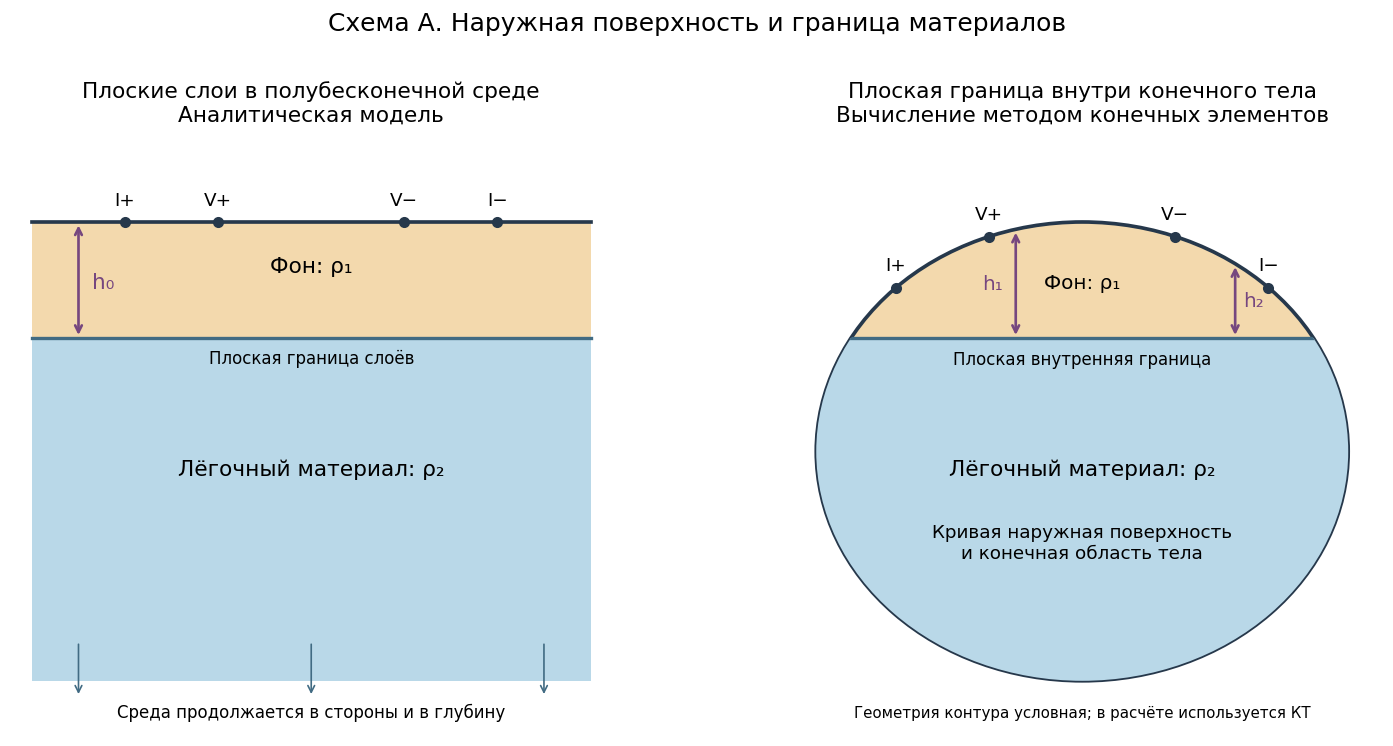

In [3]:
# An illustrative cross-section, not CT data or a field calculation.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Ellipse

_sch_fig, _sch_axes = plt.subplots(1, 2, figsize=(13, 6.3))
_sch_background, _sch_lung = '#f3d9ad', '#b9d8e8'
_sch_depth = 1.75
_sch_x = np.array([-2.8, -1.4, 1.4, 2.8])
_sch_names = ['I+', 'V+', 'V−', 'I−']
for _sch_ax in _sch_axes:
    _sch_ax.set(xlim=(-4.5, 4.5), ylim=(7.7, -1.15))
    _sch_ax.set_aspect('equal'); _sch_ax.axis('off')

_sch_ax = _sch_axes[0]
_sch_ax.add_patch(Rectangle((-4.2, 0), 8.4, _sch_depth, facecolor=_sch_background))
_sch_ax.add_patch(Rectangle((-4.2, _sch_depth), 8.4, 5.15, facecolor=_sch_lung))
_sch_ax.plot([-4.2, 4.2], [0, 0], color='#26384b', lw=2.2)
_sch_ax.plot([-4.2, 4.2], [_sch_depth]*2, color='#416b83', lw=2)
_sch_ax.scatter(_sch_x, np.zeros(4), s=32, color='#26384b', zorder=5)
for _sch_xi, _sch_name in zip(_sch_x, _sch_names):
    _sch_ax.text(_sch_xi, -.2, _sch_name, ha='center', va='bottom', fontsize=11)
_sch_ax.text(0, .75, 'Фон: ρ₁', ha='center', fontsize=13)
_sch_ax.text(0, 3.8, 'Лёгочный материал: ρ₂', ha='center', fontsize=13)
_sch_ax.annotate('', xy=(-3.5, 0), xytext=(-3.5, _sch_depth),
                 arrowprops=dict(arrowstyle='<->', color='#76477f', lw=1.6))
_sch_ax.text(-3.3, .9, 'h₀', color='#76477f', fontsize=13, va='center')
_sch_ax.text(0, 2.12, 'Плоская граница слоёв', ha='center', fontsize=10)
for _sch_xi in [-3.5, 0, 3.5]:
    _sch_ax.annotate('', xy=(_sch_xi, 7.15), xytext=(_sch_xi, 6.3),
                     arrowprops=dict(arrowstyle='->', color='#416b83'))
_sch_ax.text(0, 7.45, 'Среда продолжается в стороны и в глубину',
             ha='center', fontsize=10)
_sch_ax.set_title('Плоские слои в полубесконечной среде\nАналитическая модель',
                  fontsize=13, pad=15)

_sch_ax = _sch_axes[1]
_sch_body = Ellipse((0, 3.45), 8, 6.9, facecolor=_sch_background,
                    edgecolor='#26384b', linewidth=2.2)
_sch_ax.add_patch(_sch_body)
_sch_deep = Rectangle((-4.2, _sch_depth), 8.4, 5.5, facecolor=_sch_lung)
_sch_ax.add_patch(_sch_deep); _sch_deep.set_clip_path(_sch_body)
_sch_boundary, = _sch_ax.plot([-4.2, 4.2], [_sch_depth]*2, color='#416b83', lw=2)
_sch_boundary.set_clip_path(_sch_body)
_sch_skin = lambda x: 3.45 - 3.45*np.sqrt(1-(np.asarray(x)/4)**2)
_sch_ax.scatter(_sch_x, _sch_skin(_sch_x), s=32, color='#26384b', zorder=5)
for _sch_xi, _sch_name in zip(_sch_x, _sch_names):
    _sch_ax.text(_sch_xi, _sch_skin(_sch_xi)-.2, _sch_name,
                 ha='center', va='bottom', fontsize=11)
_sch_ax.text(0, 1.0, 'Фон: ρ₁', ha='center', fontsize=12)
_sch_ax.text(0, 3.8, 'Лёгочный материал: ρ₂', ha='center', fontsize=13)
_sch_ax.text(0, 2.13, 'Плоская внутренняя граница', ha='center', fontsize=10)
for _sch_xi, _sch_label in [(-1.0, 'h₁'), (2.3, 'h₂')]:
    _sch_z = float(_sch_skin(_sch_xi))
    _sch_ax.annotate('', xy=(_sch_xi, _sch_z), xytext=(_sch_xi, _sch_depth),
                     arrowprops=dict(arrowstyle='<->', color='#76477f', lw=1.6))
    _sch_ax.text(_sch_xi+(-.5 if _sch_label=='h₁' else .12), (_sch_z+_sch_depth)/2, _sch_label,
                 color='#76477f', fontsize=12, va='center')
_sch_ax.text(0, 5.05, 'Кривая наружная поверхность\nи конечная область тела',
             ha='center', fontsize=11)
_sch_ax.text(0, 7.45, 'Геометрия контура условная; в расчёте используется КТ',
             ha='center', fontsize=9)
_sch_ax.set_title('Плоская граница внутри конечного тела\nВычисление методом конечных элементов',
                  fontsize=13, pad=15)
_sch_fig.suptitle('Схема А. Наружная поверхность и граница материалов', fontsize=15, y=.98)
_sch_fig.tight_layout(rect=(0, 0, 1, .94))
plt.show()


**Схема А. Наружная и внутренняя границы двух постановок.** Показаны
условные сечения трёхмерных областей, без анатомического масштаба.
Бежевый цвет обозначает фон с сопротивлением $\rho_1$, голубой —
лёгочный материал с $\rho_2$. Чёрные точки обозначают токовые и
измерительные электроды. Слева плоскими являются обе границы, поэтому
$h_0$ постоянно. Справа плоская только граница материалов; две стрелки
$h_1,h_2$ показывают разные расстояния от кривой кожи до одной плоскости.
Эти индексы обозначают два места измерения толщины, а не номера тканей.

Схема иллюстрирует определения, а не новую сегментацию или результат FEM.
Её контур условный; сохраняемая дальняя часть КТ-маски отдельно не
нарисована. Расчётный вариант определяется полной формулой
$\Omega_{\mathrm{л},\mathrm P}$ выше. Ни величину импеданса, ни точность
модели по такой схеме определить нельзя. Следующий шаг — проверить
упрощения относительно общего КТ-референса и прежней двуслойной модели
по раздельным критериям, описанным в разделе 7.

**Следствие для описания тканей под сборкой.** В реальной геометрии
меняются и поверхность кожи, и поверхность лёгкого; вблизи его края
некоторые лучи вообще перестают пересекать ближнюю лёгочную область.
Переменная толщина сама по себе не определяет трёхмерное поле. Ток
растекается между соседними участками объёма, поэтому среднее из
нескольких значений $h$ или из слоистых формул нужно проверять как
отдельное приближение. Эллипсоид и другие кривые поверхности добавляют
геометрическую информацию, но полезность этого добавления определяется
уменьшением ошибок сопротивлений, а не только сходством контуров.


## 4. Пространственные упрощения лёгочной области

Проверены четыре варианта на одной и той же поверхности тела. Исходная
КТ-маска задаёт численный референс. Во втором варианте ближняя лёгочная область
заменяется полупространством с плоской границей, проходящей через первый вход
центрального луча в лёгкое. Эта область ограничивается существующим телом;
она отличается от бесконечного аналитического полупространства.

Два других варианта используют конечный замкнутый эллипсоид. Его центр и
ориентация определяются по объёмно-взвешенным моментам ближней части маски.
Отношения полуосей задаются собственными значениями ковариационной матрицы,
а общий масштаб — равенством непрерывного объёма эллипсоида объёму этой части
маски. Для равномерного эллипсоида полуоси связаны с собственными значениями
$\lambda_i$ как $a_i=\sqrt{5\lambda_i}$ до общего масштабирования.

В четвёртом варианте тот же эллипсоид сдвигается вдоль внутреннего направления
так, чтобы первая граница на центральном луче совпала с КТ. Полуоси и
ориентация сохраняются. Ни один геометрический параметр не подбирается
по электрическому импедансу.

Исходный STL содержит оба лёгких как один связанный компонент. Поэтому
«ближняя часть» определяется вспомогательным геометрическим правилом.
Для центров лёгочных тетраэдров вычисляется координата $d$ вдоль внутреннего
направления сборки. Разделяющая плоскость проходит через середину между
минимальной и максимальной координатами $d$. Исходные лёгочные тетраэдры за этой
плоскостью включаются в каждый вариант без удаления. Итоговая лёгочная
область образуется объединением этой части маски с выбранным упрощением;
упрощение может добавлять лёгочный материал и за разделяющей плоскостью.
Такое разделение не является подтверждённой сегментацией правого и левого
лёгкого.

При назначении материала центр каждого тетраэдра проверяется на попадание
в исследуемую область. Поэтому объём после дискретизации и ограничения
телом может отличаться от непрерывного объёма эллипсоида. Все варианты
по-прежнему требуют индивидуальной КТ для наружной границы и сохраняемой
части лёгких; они проверяют достаточность упрощения, а не исключение КТ.

**Связь с кривизной и диафрагмой.** Эллипсоид задаёт переменную глубину
входа в лёгкое, кривизну в двух направлениях и конечную протяжённость
лёгочной области. Вышедший из неё луч снова попадает в материал с
сопротивлением $\rho_1$. Поэтому последовательность «фон — лёгкое — фон»
содержит три геометрических участка, но только два электрических материала.
Это соответствует принятому объединению поддиафрагмальных тканей с фоном.
Отдельная геометрическая поверхность купола диафрагмы здесь не выделена:
её электрически существенная роль представлена окончанием лёгочной маски.
Замкнутый эллипсоид может воспроизводить этот край лишь приближённо.

Равенство объёмов проверяет интегральный геометрический признак. Оно не
проверяет, на какой глубине и в каких участках токового поля расположен
этот объём. Поэтому таблицу объёмов ниже следует читать совместно с
профилями границ и последующими электрическими результатами.


,Геометрия,"Объём лёгочного материала, л"
0,КТ: исходная граница лёгкого,4.21673
1,Плоская граница в объёме тела,18.2987
2,Эллипсоид по объёму и моментам,4.19787
3,Эллипсоид с привязкой по глубине,4.19715


Полуоси эллипсоида: 58.37, 88.22, 108.44 мм. Сдвиг для привязки по глубине: -1.520 мм. Центральная глубина первого входа от опорной точки: 30.897 мм.

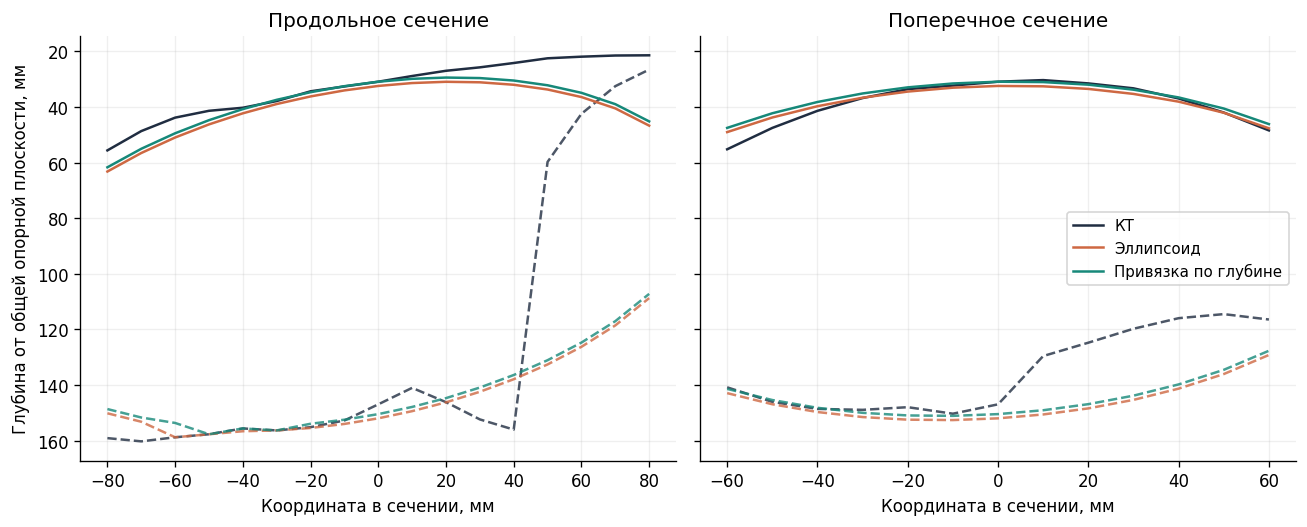

In [4]:
volumes=pd.DataFrame({'model':geometry['model_names'],'volume':list(geometry['model_lung_volumes_litres'].values())})
table(volumes,{'model':'Геометрия','volume':'Объём лёгочного материала, л'})
display(Markdown(f"Полуоси эллипсоида: {', '.join(f'{x:.2f}' for x in geometry['ellipsoid_radii_mm'])} мм. Сдвиг для привязки по глубине: {geometry['anchoring_shift_mm']:.3f} мм. Центральная глубина первого входа от опорной точки: {geometry['central_entry_depth_mm']:.3f} мм."))
rays=pd.read_csv(OUT/'ray_diagnostics.csv')
fig,axes=plt.subplots(1,2,figsize=(11,4.5),sharey=True)
for ax,coordinate,condition,title in [(axes[0],'s_mm',rays.t_mm==0,'Продольное сечение'),(axes[1],'t_mm',rays.s_mm==0,'Поперечное сечение')]:
    section=rays[condition].sort_values(coordinate)
    for suffix,label,color in [('reference','КТ','#202d41'),('ellipsoid','Эллипсоид','#ce6842'),('anchored','Привязка по глубине','#168879')]:
        ax.plot(section[coordinate],section['entry_'+suffix+'_mm'],label=label,color=color)
        ax.plot(section[coordinate],section['exit_'+suffix+'_mm'],color=color,linestyle='--',alpha=.8)
    ax.set(xlabel='Координата в сечении, мм',title=title);ax.grid(alpha=.2)
axes[0].set_ylabel('Глубина от общей опорной плоскости, мм');axes[0].invert_yaxis();axes[1].legend(fontsize=9)
fig.tight_layout();plt.show()


### Рисунок 1. Вход и выход из лёгочной области в двух сечениях

**Что показано.** Слева дано продольное сечение вдоль сборки ($t=0$),
справа — поперечное ($s=0$). Координаты $s$ и $t$ направлены вдоль сборки
и поперёк неё, $d$ — внутрь тела. Сплошные линии обозначают первый вход
луча в лёгочный материал, штриховые — выход из первого непрерывного
интервала этого материала. Цвет различает КТ, эллипсоид по объёмным моментам
и эллипсоид после привязки по центральной глубине. Направление увеличения
глубины на вертикальной оси обращено вниз.

**Как анализировать.** Сравнивать следует сплошные линии между собой,
а затем — расстояния от сплошной до соответствующей штриховой линии.
Первое характеризует различие глубины появления лёгкого, второе —
протяжённость первого лёгочного интервала. Совпадение в центре не означает
совпадения формы по всей длине или ширине сборки. Резкий скачок может
означать изменение порядка пересечений сложной маски; его нельзя
автоматически трактовать как разрыв анатомической поверхности.

**Результат модели.** В центре КТ даёт вход на глубине 30,897 мм,
исходный эллипсоид — 32,416 мм. Сдвиг на −1,520 мм устраняет это различие
в одной точке. Однако глубина первого выхода остаётся различной:
146,915 мм для КТ и 150,431 мм для привязанного эллипсоида. Следовательно,
даже центральная привязка входа не обеспечивает совпадения толщины
лёгочного интервала, тем более его продольной и поперечной формы.

**Допущения и ограничения.** Для эллипсоидальных вариантов показано
объединение эллипсоида с сохраняемой дальней частью КТ-маски. За первым
интервалом могут находиться дополнительные пересечения; эти линии не
заменяют полную материальную маску в FEM. Показаны непрерывные границы до
ограничения телом и назначения материала по центрам тетраэдров. Глубина
отсчитывается от общей опорной плоскости, а не от локальной кривой кожи.
Поэтому она не равна автоматически анатомической толщине «кожа–лёгкое».
Отсутствующие пересечения отображаются разрывами. Два сечения не описывают
весь трёхмерный объём чувствительности.

**Следующий шаг.** Проверить карту входа и выхода по площади сборки,
разделить несоответствие ближней границы и конечного края лёгкого, а затем
оценить электрическую значимость каждого различия. Уменьшать только
центральное геометрическое отклонение недостаточно для обоснования
точности $\rho_1$ и $\rho_2$.


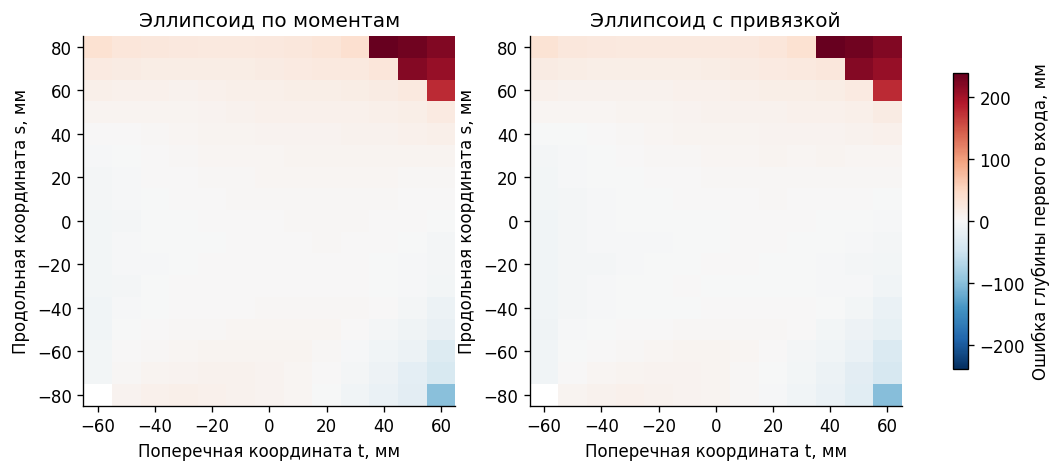

In [5]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
fields=[rays.entry_ellipsoid_mm-rays.entry_reference_mm,rays.entry_anchored_mm-rays.entry_reference_mm]
limit=max(np.nanmax(abs(x)) for x in fields)
for ax,values,title in zip(axes,fields,['Эллипсоид по моментам','Эллипсоид с привязкой']):
    data=rays.assign(error=values).pivot(index='s_mm',columns='t_mm',values='error')
    pic=ax.pcolormesh(data.columns,data.index,data.values,cmap='RdBu_r',vmin=-limit,vmax=limit,shading='nearest')
    ax.set(xlabel='Поперечная координата t, мм',ylabel='Продольная координата s, мм',title=title)
fig.colorbar(pic,ax=list(axes),label='Ошибка глубины первого входа, мм',shrink=.8)
plt.show()


### Рисунок 2. Пространственное различие глубины первого входа

**Что показано.** Каждая точка карты соответствует лучу, заданному
продольной координатой $s$ и поперечной координатой $t$. Цвет показывает
разность «глубина первого входа в упрощении минус глубина первого входа
в КТ», мм. Слева рассматривается исходный эллипсоид, справа — привязанный.
Диапазон координат составляет −80…80 мм вдоль сборки и −60…60 мм поперёк,
шаг между лучами — 10 мм. Обе панели используют одну цветовую шкалу.

**Как анализировать.** Красный цвет означает более позднее появление
лёгочного материала в упрощении, синий — более раннее; светлый участок
соответствует близким глубинам. Сначала необходимо проверить, что обе
модели пересекают одну и ту же ближнюю область. Если ближнее пересечение
исчезло и первым стало пересечение сохраняемой дальней части маски,
цвет характеризует смену пересечения, а не малое смещение одной границы.
Пустое значение при отсутствии пересечения не следует принимать за нулевую
ошибку.

**Результат модели.** При $s=80$ мм и $t=40$ мм первый вход КТ находится
на глубине 30,266 мм, а у обоих эллипсоидальных вариантов — 269,104 мм.
Разность около +238,838 мм возникает при переходе к дальней части маски.
Она не означает, что грудная стенка стала толще на 239 мм. Глобальный
сдвиг на 1,520 мм исправляет центральную точку, но не возвращает пропущенную
ближнюю область у этого края. Поэтому обе карты визуально близки.

**Допущения и ограничения.** Это геометрическая карта первого пересечения,
без весов электрической чувствительности. Она не показывает локальный
вклад участка в измеряемый импеданс. Общая шкала примерно ±239 мм делает
миллиметровые различия в центре малозаметными. Точность лучевых пересечений
и непрерывной границы не равна точности её тетраэдрального представления.
Пространственная область карты также не является доказанной границей
объёма чувствительности сборки.

**Следующий шаг.** Отдельно оценить участки с совпадающим ближним
пересечением и участки его потери; для первых сравнить миллиметровые
отклонения, для вторых — положение конечного края лёгкого. Затем проверить,
какие из этих участков влияют на отклик каждой сборки. Это позволит
обосновать набор геометрических признаков для сокращённой модели.

## 5. Отдельная проверка электродного приближения

Сравнение конечных контактов с точечными выполнено при исходной КТ-маске
и номинальных сопротивлениях. Дополнительно рассчитаны точечные электроды
в узлах, ближайших к исходным запрошенным координатам площадок. Разность
двух точечных вариантов оценивает изменение эффективного положения, а
разность CEM и точек у центроидов включает конечную площадь, контактное
условие и остаточную ошибку совмещения узлов.

Это сравнение не является пределом при непрерывном уменьшении площади:
точечный узел и конечная площадка представляют разные дискретные условия.
Отдельный тест по размеру контакта и сгущению сетки остаётся необходимым.
**Выбор по разделу 5.** CEM здесь служит расчётной опорой для конечных
контактов; её нельзя объявить экспериментальным победителем по сравнению
с собственным результатом. Среди двух точечных приближений ближе к CEM
вариант у центроидов площадок: среднеквадратичное расхождение по девяти
размерам составляет 5,596 Ом против 8,758 Ом у точек в запрошенных
координатах. Максимальные абсолютные расхождения равны соответственно
13,000 и 21,805 Ом. Следовательно, при выборе точечного приближения
для данного монтажа предпочтителен вариант у центроидов по этой метрике.
Его достаточная точность для восстановления тканей этим не установлена.
Раздел 5 сравнивает электродные условия при одной КТ-маске; выбор
геометрического упрощения лёгкого выполняется в других разделах.


,"Размер, мм","CEM, Ом","Точки у центроидов, Ом","Точки у запрошенных координат, Ом","CEM − точки у центроидов, Ом"
0,50,99.1693,94.0107,108.194,5.15857
1,60,98.9473,85.9474,89.8735,12.9999
2,70,87.8721,92.1266,66.0673,-4.25455
3,80,68.083,65.8018,68.0117,2.28116
4,90,65.9362,61.0679,61.0679,4.86824
5,110,61.306,57.7825,61.519,3.52352
6,120,58.8039,60.5935,57.8527,-1.78958
7,130,55.4996,51.3468,51.3468,4.15282
8,140,53.0165,50.495,56.0606,2.52149


Максимальное расстояние от центроида до выбранного узла: **3.072 мм**. Воспроизведение прежнего двухтканного CEM: максимальное расхождение **1.09e-08 Ом**.

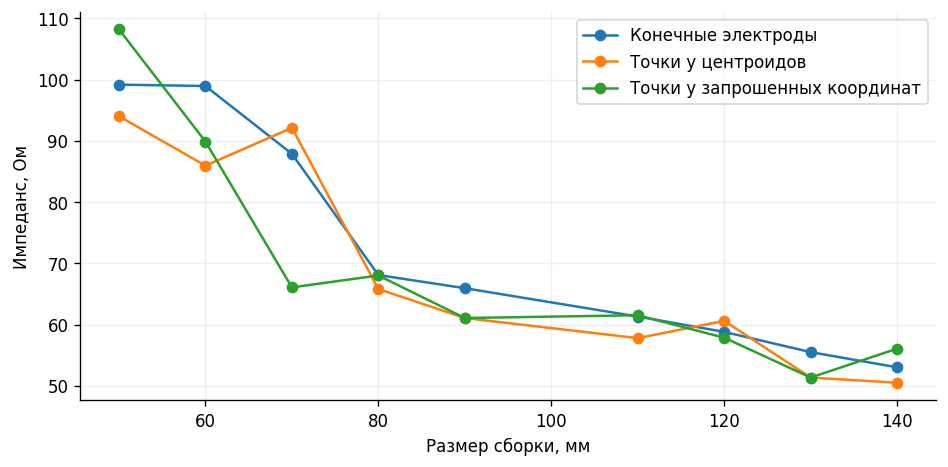

In [6]:
contacts=pd.read_csv(OUT/'contacts.csv');contact=pd.read_csv(OUT/'contact_comparison.csv')
table(contact,{'L_mm':'Размер, мм','Z_cem_ohm':'CEM, Ом','Z_centroid_pem_ohm':'Точки у центроидов, Ом','Z_requested_pem_ohm':'Точки у запрошенных координат, Ом','CEM_minus_centroid_PEM_ohm':'CEM − точки у центроидов, Ом'})
display(Markdown(f"Максимальное расстояние от центроида до выбранного узла: **{contacts.snap_to_centroid_mm.max():.3f} мм**. Воспроизведение прежнего двухтканного CEM: максимальное расхождение **{summary['CEM_reproduction_max_abs_ohm']:.3g} Ом**."))
fig,ax=plt.subplots(figsize=(8,4))
for column,label in [('Z_cem_ohm','Конечные электроды'),('Z_centroid_pem_ohm','Точки у центроидов'),('Z_requested_pem_ohm','Точки у запрошенных координат')]:
    ax.plot(contact.L_mm,contact[column],'o-',label=label)
ax.set(xlabel='Размер сборки, мм',ylabel='Импеданс, Ом');ax.grid(alpha=.2);ax.legend();fig.tight_layout();plt.show()


### Рисунок 3. Изменение импеданса при разных электродных условиях

**Что показано.** По горизонтали отложен номинальный размер сборки, мм,
по вертикали — передаточный импеданс, Ом. Все три ряда рассчитаны при
одной исходной КТ-маске и одинаковых номинальных $\rho_1^*,\rho_2^*$.
Сравниваются конечные площадки CEM, точечные узлы у центроидов площадок
и точечные узлы у первоначально запрошенных координат.

**Как анализировать.** Вертикальное расстояние между рядами при одном
размере показывает совокупное влияние выбранных электродных условий.
Разность двух точечных рядов отражает изменение эффективных координат
после выбора узлов. Разность CEM и точек у центроидов дополнительно
включает конечную площадь, контактное условие и остаточное несовпадение
положений. Линии соединяют девять отдельных расчётов и не доказывают
непрерывную зависимость от размера.

**Результат модели.** Разность CEM и точек у центроидов меняется от
−4,255 до +13,000 Ом. Для 70 мм перестановка точечных узлов из варианта
у центроидов в вариант у запрошенных координат меняет импеданс примерно
с 92,127 до 66,067 Ом. Эти различия существенно больше остатка 0,218–0,275 Ом
при последующей подгонке эллипсоидальных моделей. Следовательно, сравнение
геометрических упрощений требует согласованных электродных условий.

**Допущения и ограничения.** Немонотонность ряда сама по себе не
устанавливает физиологический механизм: здесь состояние тканей фиксировано,
а с размером меняются электроды на кривой дискретной поверхности. Расхождение
нельзя полностью приписать одному контактному сопротивлению или только
площади. Воспроизведение прежнего CEM с ошибкой порядка $10^{-8}$ Ом
является самоконтролем реализации на тех же входах; оно не подтверждает
точность реальной наклейки электродов либо сеточную сходимость.

**Следующий шаг.** Раздельно проверить сгущение сетки у контактов,
непрерывное изменение координат и уменьшение площади при согласованных
центрах. Основное сравнение геометрий ниже сохраняет один и тот же
точечный монтаж, чтобы не добавлять к нему эти изменения.

## 6. Нормированная библиотека прямого оператора

Для фиксированной геометрии $G$ и точечных токовых условий справедливо
точное масштабирование:

$$Z_L(\rho_1,\rho_2;G)=\rho_1 f_L(q;G),\qquad q=\rho_2/\rho_1,$$
где $L$ — размер сборки, $q$ — безразмерный контраст,
$f_L$ — нормированный отклик, м⁻¹. Одновременное умножение обоих
сопротивлений на одно число умножает потенциалы на это же число при
неизменном токе. Поэтому библиотека строится по одному параметру $q$.
Для CEM с фиксированным $z_c$ такое сокращение здесь не используется.

В линейном FEM нормированная матрица имеет вид
$K(q)=K_1+q^{-1}K_2$, где $K_1$ и $K_2$ — геометрические матрицы
нелёгочной и лёгочной областей при единичной проводимости. Для каждого
контраста выполняется одно разложение матрицы и решаются задачи всех
девяти возбуждений и девяти сопряжённых возбуждений.

Для токовых векторов $b_d,b_a$ и решений $Ku_d=b_d$, $Ku_a=b_a$:

$$f_L=b_a^Tu_d,\qquad
\frac{\partial f_L}{\partial\ln q}=q^{-1}u_a^TK_2u_d,$$
где $d$ обозначает исходную токовую пару, $a$ — возбуждение через
измерительную пару с согласованным знаком. Эта производная используется
при кубической интерполяции Эрмита по $\ln q$ и проверяется независимыми
центральными разностями с двумя шагами.

Интерполяционная сетка содержит 19 контрастов от 0,5 до 32. Проверочные
контрасты и три синтетических случая рассчитываются отдельно и не входят
в узлы интерполяции. Численный предел поиска задан для исследования и
не является диапазоном физиологических свойств. За него интерполяция
не продолжается.

Плоские аналитические варианты из 20.10 вычисляются своим ядром: постоянная
глубина, средняя глубина по паре, среднее двухслойное ядро и средние глубина
с конечной толщиной лёгкого. Для них строится отдельная более плотная
таблица. Эти формулы предполагают номинальные точки на плоскости; сравнение
с пространственным FEM включает различия наружной границы и монтажа.

**Как читать следующие проверки.** В первой таблице малая ошибка означает,
что интерполяция воспроизводит исходный расчёт между узлами библиотеки.
Во второй таблице сравниваются два способа вычисления одной производной;
согласие при двух шагах уменьшает вероятность ошибки дифференцирования.
Наибольшая проверенная ошибка интерполяции около 0,000213 Ом значительно
меньше наблюдаемых межмодельных различий. Поэтому она не объясняет большие
смещения сопротивлений в этом опыте. Однако обе проверки относятся к
численному оператору на фиксированной сетке и не заменяют проверку
физической адекватности геометрии и контактов.
**Смысл нуля в однородном пределе.** При $q=1$ оба материала имеют
одинаковое сопротивление, поэтому перенос внутренней границы не меняет
пространственный оператор с общей наружной поверхностью и электродами.
Нулевое различие четырёх пространственных моделей в этом тесте не
означает нулевую ошибку плоской модели при неоднородных тканях.


In [7]:
validation=pd.read_csv(OUT/'interpolation_validation.csv')
table(validation.groupby('model',sort=False)[['max_abs_ohm','max_relative']].max().reset_index(),{'model':'Модель','max_abs_ohm':'Максимальная ошибка интерполяции, Ом','max_relative':'Максимальная относительная ошибка'})
qc=pd.read_csv(OUT/'derivative_qc.csv')
table(qc,{'log_step':'Шаг по логарифму контраста','adjoint':'Сопряжённая производная','finite_difference':'Центральная разность','relative_error':'Относительное расхождение'})
display(Markdown(f"В однородном пределе различие пространственных моделей составляет не более {summary['homogeneous_model_spread_ohm_per_ohm_m']:.3g} м⁻¹. Проверка интерполяции выполнена независимо от её узлов; сходимость исходной объёмной сетки этим не проверяется."))


,Модель,"Максимальная ошибка интерполяции, Ом",Максимальная относительная ошибка
0,КТ: исходная граница лёгкого,1.87409e-05,3.85961e-07
1,Плоская граница в объёме тела,5.42701e-05,1.06936e-06
2,Эллипсоид по объёму и моментам,1.94442e-05,4.33989e-07
3,Эллипсоид с привязкой по глубине,2.08588e-05,4.61892e-07
4,Аналитика: постоянная глубина,4.04601e-08,7.72433e-10
5,Аналитика: средняя глубина по паре,8.39233e-06,1.46117e-07
6,Аналитика: среднее двухслойное ядро,2.72713e-06,5.1644e-08
7,Аналитика: конечная толщина лёгкого,0.000212726,4.18565e-06


,Шаг по логарифму контраста,Сопряжённая производная,Центральная разность,Относительное расхождение
0,0.001,0.6559,0.6559,4.35058e-07
1,0.0005,0.6559,0.655899,1.15852e-06


В однородном пределе различие пространственных моделей составляет не более 0 м⁻¹. Проверка интерполяции выполнена независимо от её узлов; сходимость исходной объёмной сетки этим не проверяется.

## 7. Восстановление сопротивлений и различия классов моделей


### 7.1. Раздельное сравнение постановок и восстановленных параметров

Постановки показаны на схеме А и определены формулами раздела 3.1.
Обозначение «пространственные модели» в таблицах и рисунках означает
варианты с общей индивидуальной наружной поверхностью, объёмной сеткой
и узловыми электродами. «Аналитические приближения» используют номинальные
точки на плоскости и формулы слоистой полубесконечной среды.

Это различие определяет два самостоятельных сравнения. Внутри группы
КТ/FEM изменяется маска материалов при согласованных внешней границе
и электродах; так исследуется вклад внутренней геометрии. При сравнении
с прежней аналитической моделью оценивается весь способ расчёта вместе
с его наружной геометрией и монтажом. Второе сравнение нужно для цели
улучшения прежнего метода, но его расхождение нельзя полностью приписать
кривизне лёгкого.

Для всех кандидатов используются одни синтетические наблюдения и известные
сопротивления. Прежняя модель участвует в испытании наравне с кандидатами.
Для каждого сопротивления выигрыш кандидата относительно неё можно
представить как разность модулей относительных ошибок:

$$D_j=|e_{j,\mathrm{прежняя}}|-|e_{j,\mathrm{кандидат}}|,\qquad j=1,2,$$
где $e_j$ — ошибка из раздела 1, а $D_j$ выражается в процентных пунктах.
Положительное $D_j$ означает уменьшение ошибки данного сопротивления,
отрицательное — ухудшение. Проверка проводится при одинаковых исходных
параметрах, данных и правилах инверсии; физиологические ограничения
должны быть общими для моделей. Малый остаток импеданса не подменяет
эту проверку свойств тканей.

Новая модель должна проходить физиологический критерий и улучшать требуемую
точность на заявленном наборе условий. Если один параметр улучшается,
а другой ухудшается, предпочтение требует заранее принятого допуска
для обоих. В данном опыте такие допуски и численные физиологические
границы ещё не установлены. Поэтому ниже сначала приводятся раздельные
ошибки и отрицательные результаты, без назначения практического победителя.

### 7.2. Что означают четыре аналитических варианта

| Вариант | Сокращение геометрической информации | Что требуется проверить |
|---|---|---|
| Постоянная глубина | Одна величина $h$ для двуслойной полубесконечной среды | Достаточность одной глубины для всех токовых и измерительных пар |
| Средняя глубина | Для каждой пары используется усреднённая по пути глубина | Допустимость замены меняющейся глубины её средним значением внутри нелинейного ядра |
| Среднее двухслойное ядро | Усредняются отклики слоистой функции Грина при локальных глубинах | Соответствие такого усреднения полю у реальной кривой границы |
| Конечный лёгочный интервал | Усредняются глубина входа и протяжённость первого лёгочного интервала; используется последовательность $\rho_1$–$\rho_2$–$\rho_1$ | Достаточность плоского конечного слоя для описания края лёгкого |

В последней строке три слоя содержат только два типа тканей: первый и
третий имеют одно $\rho_1$. Это приближение конечной лёгочной области,
но не отдельная модель третьего материала под диафрагмой. Ни одно из
усреднений не описывает автоматически наклонный или куполообразный край
лёгкого во всём объёме токового поля.

Сравнение внутри пространственной группы изолирует изменение материальной
маски при общих наружной границе и точечных узлах. Сравнение этой группы
с аналитической дополнительно меняет наружную геометрию и фактические
координаты электродов. Поэтому его результат нельзя считать чистой оценкой
ошибки кривизны или преимуществ одного решателя.

### 7.3. Как находятся два неизвестных сопротивления

Синтетические наблюдения $y_L$ формируются исходной КТ-моделью с точечными
электродами при заданных $\rho_1^*,\rho_2^*$. Геометрия каждого упрощения
остаётся фиксированной. При выбранном контрасте положительный масштаб
оценивается методом наименьших квадратов:

$$\widehat\rho_1(q)=\frac{\sum_{L\in\mathcal I} f_L(q)y_L}
{\sum_{L\in\mathcal I} f_L(q)^2},\qquad
\widehat\rho_2(q)=q\widehat\rho_1(q),$$
где $\mathcal I$ — используемые размеры, $y_L$ выражены в Ом,
$f_L$ — в м⁻¹, восстановленные сопротивления — в Ом·м.
При неположительном числителе допустимый масштаб ограничивается малым
положительным числом. В данном опыте найденные решения положительны.

Затем минимизируется сумма квадратов остатков по $\ln q$. Поиск рассматривает
все минимумы, разрешённые предварительной сеткой из 301 точки, и оба края
интервала. Каждый внутренний кандидат уточняется ограниченной одномерной
минимизацией. Это численный поиск в заданном диапазоне, без доказательства
глобальной единственности за его пределами. Решения на границе помечаются.

Все размеры имеют одинаковый вес. Это определение вычислительной метрики,
а не предположение о независимом гауссовском шуме прибора. Остаток в таблице
означает среднеквадратичное расхождение по девяти размерам:

$$\mathrm{RMSE}_Z=\sqrt{\frac1{9}\sum_L
\bigl[Z_L(\widehat\rho_1,\widehat\rho_2)-y_L\bigr]^2},$$
где $\mathrm{RMSE}_Z$ выражается в Ом и характеризует совпадение импедансов.
Ошибки $e_1,e_2$ из раздела 1 отдельно характеризуют правильность
восстановленных свойств материалов. Малость одного критерия не гарантирует
малости остальных.


,Модель,"ρ₁, Ом·м","ρ₂, Ом·м","Ошибка ρ₁, %","Ошибка ρ₂, %","Остаток по девяти размерам, Ом",Контраст на границе
0,КТ: исходная граница лёгкого,5.55217,30.707,1.01484e-06,0.000130859,2.84604e-07,Нет
1,Плоская граница в объёме тела,5.68699,10.823,2.42838,-64.7539,0.666759,Нет
2,Эллипсоид по объёму и моментам,5.58927,65.426,0.66834,113.066,0.274711,Нет
3,Эллипсоид с привязкой по глубине,5.56944,48.3115,0.311077,57.331,0.218446,Нет
4,Аналитика: постоянная глубина,5.54992,30.1519,-0.0404237,-1.80743,6.13403,Нет
5,Аналитика: средняя глубина по паре,5.55606,28.3175,0.0701578,-7.78148,6.13917,Нет
6,Аналитика: среднее двухслойное ядро,5.56565,28.7847,0.242882,-6.25982,6.14607,Нет
7,Аналитика: конечная толщина лёгкого,5.38824,54.3434,-2.95247,76.9742,6.06751,Нет


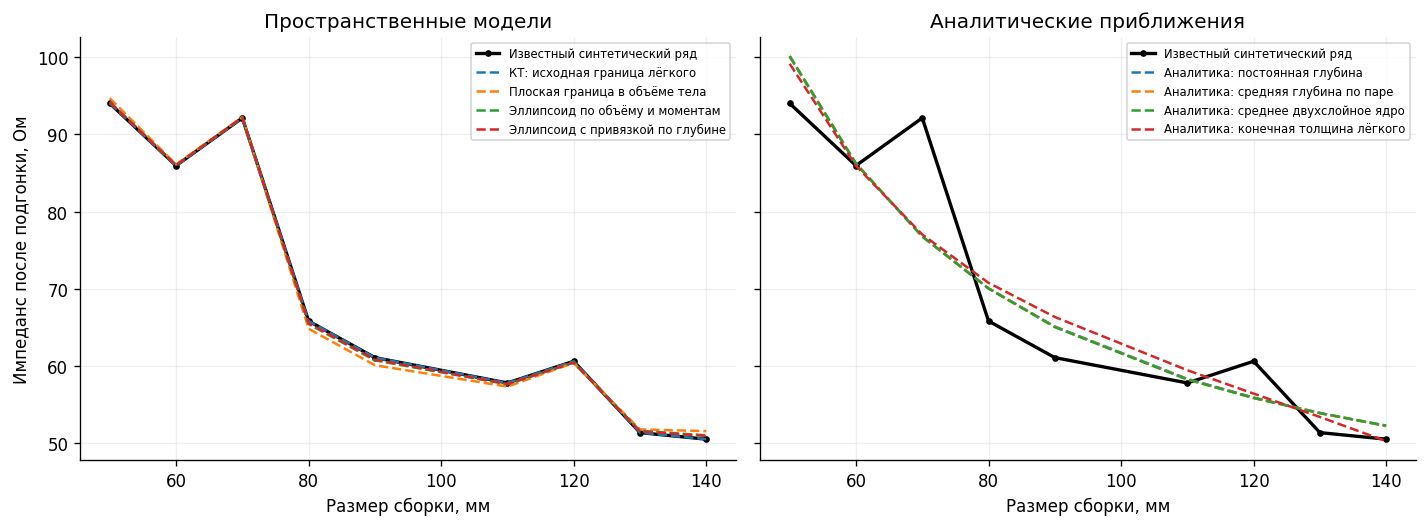

In [8]:
truth=rho1_true*curve_at(fem_tables['reference'],nominal_ratio)
recomputed=[]
for name,spline in models.items():
    result,_,_=recover(spline,truth)
    recomputed.append({'model':name,'rho1':result['rho1'],'rho2':result['rho2'],
      'e1':100*(result['rho1']/rho1_true-1),'e2':100*(result['rho2']/rho2_true-1),
      'rmse':result['all_rmse'],'bound':result['contrast_at_bound']})
recomputed=pd.DataFrame(recomputed)
saved=pd.read_csv(OUT/'inverse_recovery.csv').query('case_index==1').set_index('model')
np.testing.assert_allclose(recomputed.set_index('model')[['rho1','rho2']].loc[saved.index],saved[['rho1','rho2']],rtol=1e-9)
table(recomputed,{'model':'Модель','rho1':'ρ₁, Ом·м','rho2':'ρ₂, Ом·м','e1':'Ошибка ρ₁, %','e2':'Ошибка ρ₂, %','rmse':'Остаток по девяти размерам, Ом','bound':'Контраст на границе'})
pred=pd.read_csv(OUT/'predictions.csv').query('case_index==1')
fig,axes=plt.subplots(1,2,figsize=(12,4.5),sharey=True)
for ax,names,title in [(axes[0],geometry['model_names'],'Пространственные модели'),(axes[1],list(models)[4:],'Аналитические приближения')]:
    ax.plot(sizes,truth,'k.-',label='Известный синтетический ряд',linewidth=2)
    for name in names:
        rows=pred[pred.model==name].sort_values('L_mm');ax.plot(rows.L_mm,rows.after_fit_ohm,'--',label=MODEL_LABELS[name])
    ax.set(xlabel='Размер сборки, мм',title=title);ax.grid(alpha=.2);ax.legend(fontsize=7)
axes[0].set_ylabel('Импеданс после подгонки, Ом');fig.tight_layout();plt.show()


### Рисунок 4. Размерные зависимости после подгонки сопротивлений

**Что показано.** По горизонтали дан размер сборки, по вертикали — импеданс
после подбора $\rho_1$ и $\rho_2$ по всем девяти размерам. Чёрная линия
в обеих панелях — один и тот же синтетический ряд исходной КТ-модели
с известными сопротивлениями. Слева показаны пространственные модели,
справа — аналитические приближения. Каждая цветная линия построена при
своей найденной паре сопротивлений; это не сравнение всех моделей при
одинаковых $\rho_1,\rho_2$.

**Как анализировать.** Близость к чёрной линии означает малый остаток
подгонки. Чтобы оценить восстановление тканей, необходимо одновременно
читать столбцы ошибок $\rho_1$ и $\rho_2$ в таблице. Левую и правую панели
можно сравнивать по общей шкале импеданса, но причины различий следует
разделять согласно разделу 7.1. Неровности синтетического ряда возникают
в фиксированной дискретной постановке с меняющимися монтажами, а не
представляют измеренную физиологическую размерную зависимость.

**Результат модели.** У эллипсоида остаток равен 0,275 Ом, но
$\widehat\rho_2=65,426$ Ом·м вместо 30,707 Ом·м: ошибка составляет +113,07%.
После привязки по глубине остаток уменьшается до 0,218 Ом, а ошибка
$\rho_2$ — до +57,33%. Напротив, плоская аналитическая модель с постоянной
глубиной в этом случае даёт ошибку $\rho_2$ около −1,81%, хотя остаток
импеданса равен 6,134 Ом. Поэтому ранжирование по совпадению линий и
ранжирование по ошибке тканевого параметра здесь различаются.

**Допущения и ограничения.** Все девять точек использованы для подбора;
рисунок показывает воспроизведение обучающего размерного ряда, а не
независимый прогноз. Почти точное восстановление референсной строкой
является самоконтролем интерполяции на отдельно рассчитанном контрасте.
Её точность не означает экспериментальную валидацию FEM. Малую ошибку
$\rho_2$ у одной аналитической модели в одном случае также нельзя считать
доказательством её общей пригодности: форма ряда воспроизводится плохо,
а устойчивость к смене условий должна проверяться отдельно.

**Следующий шаг.** Сравнивать ошибки обоих параметров на нескольких
контрастах, сохранять контроль импеданса и проверять размеры, не включённые
в подгонку. Для чистого сравнения геометрии дополнительно нужны одинаковые
электродные и наружные граничные условия у сопоставляемых операторов.

## 8. Зависимость результата от тканевого контраста

### 8.1. Почему используется отношение сопротивлений

Контраст $q=\rho_2/\rho_1$ показывает, во сколько раз сопротивление лёгочного
материала выше сопротивления фона. При $q=1$ материалы электрически
неразличимы, при $q>1$ лёгкое проводит хуже фона. Это характеристика
соотношения материалов, а не самостоятельная оценка функции лёгкого.

Для фиксированной геометрии PEM выполняется точное равенство раздела 6:
$Z_L=\rho_1 f_L(q)$. Общий множитель задаёт масштаб импедансов в Ом,
а контраст — нормированное распределение поля и форму размерного ряда.
Например, одновременное удвоение обоих сопротивлений при неизменном
отношении удваивает все импедансы. Оно не требует нового решения поля
для построения нормированной библиотеки.

Это сокращение относится и к инверсии без добавленного возмущения данных
с текущим критерием.
Если весь синтетический ряд умножить на положительное число $a$, то
при каждом $q$ оптимальный масштаб $\widehat\rho_1(q)$ также умножится
на $a$, а сумма квадратов остатков — на $a^2$. Положение минимума по
$q$ и относительные ошибки обоих сопротивлений останутся прежними,
если не вводятся дополнительные ограничения на абсолютные значения.
Поэтому двумерный перебор общего масштаба и контраста повторял бы часть
того же опыта без добавленного возмущения. Для возмущений, заданных в долях импеданса,
это свойство также сохраняется в данной PEM-постановке.

### 8.2. Какие абсолютные значения стоят за тремя точками

| Синтетический случай | $\rho_1^*$, Ом·м | $\rho_2^*$, Ом·м | $q^*$ |
|---|---:|---:|---:|
| Меньший контраст | 5,55217 | 15,54607 | 2,8 |
| Номинальный контраст | 5,55217 | 30,70695 | 5,53062 |
| Больший контраст | 5,55217 | 47,74863 | 8,6 |

Номинальные числа перенесены из прежнего модельного кандидата, а не
из независимого измерения сопротивлений тканей. Значения 2,8 и 8,6 выбраны
как дополнительные сценарии по обе стороны от него. Их плотность и границы
не обоснованы как физиологический диапазон. Следовательно, вычислительная
проверка выполнена при конкретных сопротивлениях в физических единицах,
но физиологическая представительность этих трёх пар остаётся открытой.

При переходе к реальным физиологическим значениям необходимо обосновать
диапазоны для соответствующих частоты, состояния дыхания и эффективной
двухтканной классификации. Частота в данном расчёте не варьируется,
сопротивления заданы действительными скалярами. При фиксированном шуме
в Ом общий масштаб меняет отношение сигнала к этому шуму; при фиксированном
контактном сопротивлении CEM простое PEM-масштабирование также не действует.
В таких постановках абсолютные $\rho_1,\rho_2$ нужно учитывать явно.

### 8.3. Какой результат считать лучшим

Для задачи восстановления тканей предпочтительно малое **абсолютное
значение относительной ошибки** каждого сопротивления на всём заранее
заданном наборе условий. Например, −65% не лучше +57% из-за меньшего
знакового числа: по модулю ошибка 65% больше 57%. Увеличение самого
контраста не является улучшением; оно меняет условия испытания.
Дополнительно нужны приемлемый остаток, прогноз неиспользованных размеров
и устойчивость к неопределённости. Численные допуски конечной методики
пока не заданы, поэтому модель нельзя объявить достаточной только по
её первому месту среди нескольких кандидатов.
### 8.4. Физиологическая допустимость как условие выбора

**Подтверждённое требование автора.** Основной интерес представляет
восстановление физиологически допустимых $\rho_1$ и $\rho_2$. Хорошая
подгонка импеданса при недопустимых сопротивлениях не делает модель
кандидатом для практической методики. Расчёты вне принятой области
сохраняются как диагностика несостоятельности упрощения или поведения
обратной задачи; они не участвуют в выборе пригодной модели наравне
с допустимыми решениями.

Проверка должна охватывать и сопротивления, заданные при генерации
основных синтетических данных, и сопротивления, полученные инверсией.
Сначала задаётся допустимая область в Ом·м для соответствующих частоты,
состояния дыхания и принятой классификации тканей. Внутри неё сравниваются
ошибки обоих параметров, остаток импеданса, прогноз и устойчивость.
Попадание в физиологическую область является необходимым, но само по себе
недостаточным условием: физиологически правдоподобная оценка также может
существенно отличаться от известного сопротивления данного объекта.

В текущем опыте численные физиологические границы для двух эффективных
материалов не установлены. Интервал контраста 0,5–32 — техническая
область поиска; он не определяет допустимость тканей. Номинальная пара
5,55217 и 30,70695 Ом·м также не является независимо подтверждённым
физиологическим эталоном. Поэтому сохранённые строки пока имеют
неоценённую физиологическую допустимость. Например, значению
65,426 Ом·м нельзя приписать статус допустимого или недопустимого
только по величине ошибки относительно номинального числа.

Для $\rho_1$ границы должны относиться ко всей эффективной нелёгочной
группе, включающей кости и поддиафрагмальные ткани, согласно постановке
автора. Диапазон одной мышцы нельзя автоматически переносить на эту
группу. Принятое объединение не отменяет требования физиологической
допустимости; оно требует обоснования диапазона именно эффективного
параметра. Согласование этих границ предшествует новому основному
ранжированию моделей.


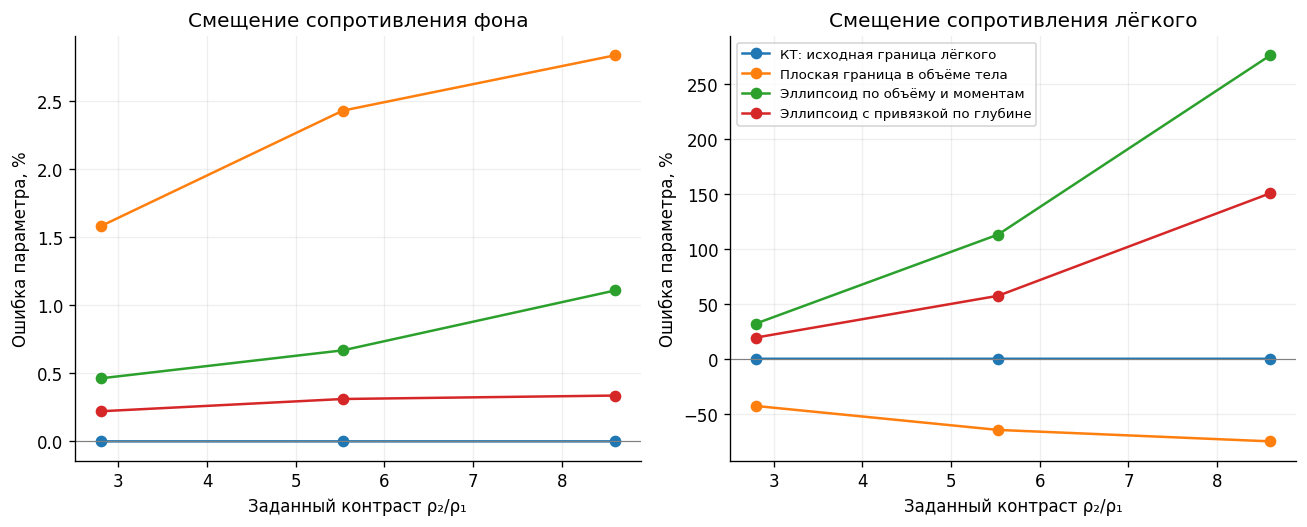

In [9]:
inverse=pd.read_csv(OUT/'inverse_recovery.csv')
fig,axes=plt.subplots(1,2,figsize=(11,4.5))
for name in geometry['model_names']:
    rows=inverse[inverse.model==name].sort_values('true_rho2')
    for ax,column in zip(axes,['rho1_error_pct','rho2_error_pct']):
        ax.plot(rows.true_rho2/rows.true_rho1,rows[column],'o-',label=MODEL_LABELS[name])
for ax,title in zip(axes,['Смещение сопротивления фона','Смещение сопротивления лёгкого']):
    ax.axhline(0,color='grey',linewidth=.7);ax.set(xlabel='Заданный контраст ρ₂/ρ₁',ylabel='Ошибка параметра, %',title=title);ax.grid(alpha=.2)
axes[1].legend(fontsize=8);fig.tight_layout();plt.show()


### Рисунок 5. Ошибки двух сопротивлений при трёх заданных контрастах

**Что показано.** По горизонтали дан известный контраст синтетических
данных из таблицы раздела 8.2; это не найденный контраст и не время
дыхательного процесса. Слева отложена относительная ошибка $\rho_1$,
справа — ошибка $\rho_2$, обе в процентах. Представлены четыре
пространственные модели с одинаковыми точечными электродами. Аналитические
приближения в этот рисунок не включены. Точки обозначают три рассчитанных
случая; соединяющие отрезки помогают чтению и не являются дополнительными
вычислениями между ними.

**Как анализировать.** Нулевая горизонталь означает правильное
восстановление. Положительная ошибка — завышение, отрицательная —
занижение сопротивления. Лучше кривая, расположенная ближе к нулю
по модулю на нужном диапазоне, при соблюдении остальных критериев.
Масштабы вертикальных осей двух панелей различны: визуально похожая
высота на них не означает одинаковый процент ошибки.


**Какая линия имеет почти нулевую ошибку.** На рисунке 5 это синяя
кривая «КТ: исходная граница лёгкого», а не плоская модель. Серая
горизонталь на нуле — ориентир идеального восстановления. Ошибка каждого
параметра вычисляется относительно сопротивления, заданного при создании
синтетических данных, по формуле раздела 1. Данные создаёт исходная
КТ-модель; затем её же геометрия используется в контрольной инверсии
через интерполяционную библиотеку. Поэтому близость синей кривой к нулю
проверяет численную согласованность и не является независимым доказательством
преимущества КТ-модели на реальных измерениях.

В номинальном случае ошибка $\rho_2$ равна примерно +0,00013% у КТ,
−64,75% у плоской границы внутри тела и −1,81% у плоской аналитической
модели с постоянной глубиной. Последняя в рисунок 5 не включена;
она представлена в таблице раздела 7. Сравнение не использует плоскую
модель в качестве источника синтетических наблюдений.

**Результат модели.** Для плоской пространственной границы ошибка
$\rho_2$ меняется примерно от −42,95% до −75,17%. У эллипсоида она
возрастает от +32,04% до +276,22%, у привязанного эллипсоида —
от +19,30% до +150,67%. В этих трёх случаях привязка улучшает исходный
эллипсоид по обоим сопротивлениям. Однако при большом контрасте плоская
граница имеет меньшую ошибку $\rho_2$ по модулю, чем оба эллипсоида,
при большей ошибке $\rho_1$. Поэтому единственного победителя по всем
параметрам и случаям нет. Близость КТ-линии к нулю — ожидаемый
результат численного самоконтроля на согласованной модели.

**Допущения и ограничения.** Для исходного эллипсоида при $q^*=8,6$
найденный контраст достигает верхней границы поиска $\widehat q=32$.
Показанная ошибка относится к ограниченному решению и не характеризует
свободный оптимум во всём положительном диапазоне. Три точки не
устанавливают монотонный закон между ними и не проверяют другую анатомию.
Высокий контраст означает меньшую проводимость лёгкого относительно фона;
перераспределение токов при этом зависит от геометрии. Наблюдаемое
ухудшение нельзя автоматически переносить на любые электродные схемы.

**Следующий шаг.** Задать обоснованный диапазон эффективных сопротивлений,
уточнить сетку контрастов и проверить область около граничных решений.
Геометрические кандидаты следует сравнивать по совместным ошибкам
$\rho_1,\rho_2$, а зависимость этих ошибок объяснять через их
чувствительности и разделимость в следующем разделе.

## 9. Чувствительность и разделимость параметров

### 9.1. Что означает производная по сопротивлению лёгкого

Для нормированного оператора получаются производные

$$\frac{\partial Z_L}{\partial\rho_1}=f_L-\frac{\partial f_L}{\partial\ln q},
\qquad
\frac{\partial Z_L}{\partial\rho_2}=q^{-1}\frac{\partial f_L}{\partial\ln q},$$
где при каждой производной второе сопротивление, геометрия и электродные
условия фиксированы. Размерность производных — м⁻¹, то есть Ом импеданса
на Ом·м удельного сопротивления. Производная описывает локальное изменение:

$$\delta Z_L\approx
\frac{\partial Z_L}{\partial\rho_1}\delta\rho_1+
\frac{\partial Z_L}{\partial\rho_2}\delta\rho_2,$$
где $\delta\rho_1,\delta\rho_2$ — достаточно малые изменения, Ом·м,
$\delta Z_L$ — соответствующее изменение импеданса, Ом. Это локальная
линеаризация при фиксированной анатомии, а не модель полного дыхательного
перехода с возможным движением границ.

Например, для исходной КТ-модели при 120 мм производная по $\rho_2$
равна примерно 0,1444 м⁻¹. Изменение только $\rho_2$ на 0,1 Ом·м
даёт в первом порядке около 0,0144 Ом. Производная по $\rho_1$ для
того же размера равна 10,115 м⁻¹: такое же абсолютное изменение фона
даёт около 1,0115 Ом. Равные абсолютные приращения не равны относительным,
поскольку сами сопротивления различаются. Для сравнения относительных
изменений используются логарифмические параметры ниже.

### 9.2. Достаточна ли большая чувствительность для точного определения

Если $\rho_1$ известно, модель верна, а ошибка импеданса одинакова,
то большая по модулю производная по $\rho_2$ обычно полезна: одно и то же
малое изменение $\rho_2$ легче отличить от ошибки измерения. При одном
неизвестном локальная оценка имеет вид
$|\delta\rho_2|\approx|\delta Z|/|\partial Z/\partial\rho_2|$.

В нашей задаче неизвестны оба сопротивления. Тогда важна не только
величина отклика на $\rho_2$, но и возможность отличить его от отклика
на $\rho_1$ по набору размеров. Если два набора производных почти
пропорциональны, изменение одного параметра компенсируется изменением
другого. Большой отклик может оставаться неоднозначным. Дополнительно
сама производная должна соответствовать реальному объекту: завышенная
чувствительность ошибочной геометрии не является преимуществом измерения.

Это можно выразить через столбцы $\mathbf j_1,\mathbf j_2$ матрицы
чувствительности к относительным изменениям сопротивлений:

$$\mathbf j_{2\perp}=
\left(I-\frac{\mathbf j_1\mathbf j_1^T}{\mathbf j_1^T\mathbf j_1}\right)
\mathbf j_2,$$
где $I$ — единичная матрица по числу размеров, $\mathbf j_1\ne0$,
а $\mathbf j_{2\perp}$ — часть отклика на $\rho_2$, которую нельзя
воспроизвести малым изменением $\rho_1$. Формула относится к текущим
равным весам в пространстве импедансов. Если этот вектор мал, совместное
разделение тканей неустойчиво даже при заметном полном $\mathbf j_2$.
Это объясняющая локальная характеристика; отдельный численный отбор
геометрии по ней в данном ноутбуке ещё не выполнен.

### 9.3. Что измеряет число обусловленности

Вводятся безразмерные параметры
$\theta_j=\ln(\rho_j/\rho_{\mathrm{ед}})$, где
$\rho_{\mathrm{ед}}=1$ Ом·м — фиксированная единица нормировки.
Малое $\delta\theta_j\approx\delta\rho_j/\rho_j$ соответствует
относительному изменению сопротивления. Матрица Якоби состоит из девяти
строк и двух столбцов:

$$J_{Lj}=\frac{\partial Z_L}{\partial\theta_j}
=\rho_j\frac{\partial Z_L}{\partial\rho_j},\qquad
J=[\mathbf j_1\ \mathbf j_2],\qquad
\kappa_2(J)=\frac{s_{\max}(J)}{s_{\min}(J)},$$
где элементы $J$ имеют размерность Ом, $s_{\max}$ и $s_{\min}$ —
наибольшее и наименьшее сингулярные числа. Они характеризуют самый
сильный и самый слабый отклики на комбинации относительных изменений
параметров одинаковой евклидовой длины. При полном ранге
$\kappa_2\ge1$; при потере ранга разделение двух направлений невозможно
и математическое число обусловленности бесконечно. Используемое
SVD-определение соответствует
[документации NumPy](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cond.html).

При $\kappa_2\approx40$ наиболее слабая комбинация относительных
изменений сопротивлений даёт примерно в 40 раз меньший отклик, чем
наиболее сильная комбинация той же длины. Это **не** означает автоматически
40% ошибки, усиление любого шума ровно в 40 раз или точность 1/40.
Абсолютная устойчивость зависит также от $s_{\min}$, уровня и направления
ошибки данных. Даже $\kappa_2=1$ может соответствовать двум одинаково
малым, плохо наблюдаемым откликам.

Число обусловленности увеличивается как при почти параллельных столбцах,
так и при сильном различии их масштабов. Оно зависит от выбора параметров,
размеров, весов и точки вычисления. Здесь применяются относительные
изменения параметров и одинаковые веса абсолютных остатков в Ом.
Таблица ниже вычислена **при найденных для каждой модели сопротивлениях**;
график производных перед ней — **при одной общей заданной номинальной
паре**. Поэтому таблица не является числовым пересказом графика.

Без установленной модели неопределённости и проверки ошибки геометрии
$\kappa_2$ служит диагностикой локальной обратной задачи. Доверительные
интервалы и границы Крамера–Рао из него здесь не выводятся.
### 9.4. Как применять чувствительность в физиологической области

Чувствительность и обусловленность следует использовать для основного
сравнения при допустимых сопротивлениях. Небольшое число обусловленности
вне этой области характеризует только математическое поведение модели.
Оно не оправдывает недопустимую оценку и не повышает её практическую
ценность. Таблица этого раздела остаётся диагностикой прежних
неограниченных физиологическими границами решений; новым ранжированием
допустимых моделей она не является.

После задания положительных границ $\rho_j^{\min},\rho_j^{\max}$
инверсия должна выполняться внутри них. При фиксированном $q>0$
допустимый интервал для масштаба имеет вид

$$\rho_1\in[\ell(q),u(q)],\qquad
\ell(q)=\max\left(\rho_1^{\min},\frac{\rho_2^{\min}}q\right),\qquad
u(q)=\min\left(\rho_1^{\max},\frac{\rho_2^{\max}}q\right),$$
где $\ell,u$ выражаются в Ом·м и учитывают одновременно границы
обоих материалов, поскольку $\rho_2=q\rho_1$. При $\ell>u$ данный
контраст недопустим. При непустом интервале решение для масштаба из
раздела 7 ограничивается этим интервалом **внутри каждого шага поиска**,
после чего заново вычисляется остаток и выбирается контраст. Простая
обрезка двух готовых оценок после прежнего поиска такой задачи не решает.

Это спецификация следующей ограниченной инверсии, не описание уже
выполненного пересчёта. Приведённая формула предполагает, что принятая
область задаётся независимыми интервалами двух сопротивлений. Если
потребуется совместное физиологическое ограничение, его нужно включить
отдельно. Выход решения на принятую границу фиксируется: он может
указывать на недостаточность модели или ограничений и не доказывает,
что ткань действительно имеет граничное сопротивление.


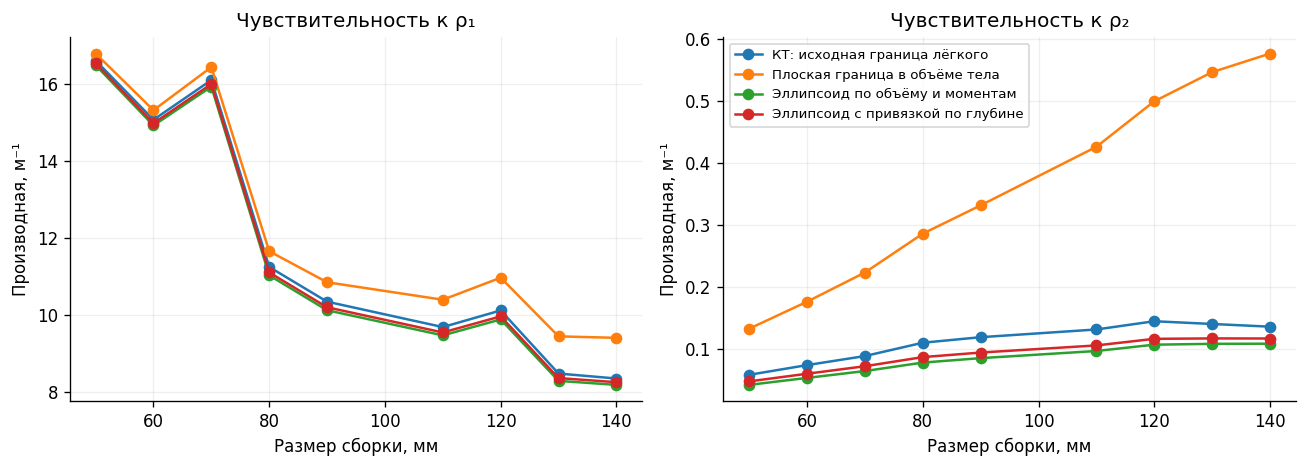

,Модель,Число обусловленности при найденных параметрах
0,КТ: исходная граница лёгкого,39.5749
1,Плоская граница в объёме тела,7.5137
2,Эллипсоид по объёму и моментам,93.1154
3,Эллипсоид с привязкой по глубине,68.0588
4,Аналитика: постоянная глубина,17.2823
5,Аналитика: средняя глубина по паре,14.6282
6,Аналитика: среднее двухслойное ядро,15.5277
7,Аналитика: конечная толщина лёгкого,29.1004


In [10]:
sens=pd.read_csv(OUT/'sensitivities.csv')
fig,axes=plt.subplots(1,2,figsize=(11,4))
for name in geometry['model_names']:
    rows=sens[sens.model==name].sort_values('L_mm')
    for ax,column in zip(axes,['dZ_drho1','dZ_drho2']):ax.plot(rows.L_mm,rows[column],'o-',label=MODEL_LABELS[name])
for ax,title in zip(axes,['Чувствительность к ρ₁','Чувствительность к ρ₂']):
    ax.set(xlabel='Размер сборки, мм',ylabel='Производная, м⁻¹',title=title);ax.grid(alpha=.2)
axes[1].legend(fontsize=8);fig.tight_layout();plt.show()
table(inverse.query('case_index==1'),{'model':'Модель','condition_log_parameters':'Число обусловленности при найденных параметрах'})


### Рисунок 6 и таблица обусловленности. Величина отклика и его однозначность

**Что показано.** Слева дана производная импеданса по сопротивлению фона,
справа — по сопротивлению лёгкого; по горизонтали отложен размер сборки.
Все четыре пространственные модели рассчитаны при одной известной паре
$\rho_1^*=5,55217$, $\rho_2^*=30,70695$ Ом·м. Второй параметр при
дифференцировании фиксирован. Вертикальные шкалы двух панелей различаются.

**Как анализировать.** Высота правой кривой показывает, насколько сильно
меняется импеданс при малом изменении только $\rho_2$. Для проверки
упрощения нужно оценивать её близость к КТ-кривой по величине и форме,
а не выбирать максимальную высоту. Для выбора размеров нужны оба
столбца производных: измерения должны различать изменения двух тканей.
Неравномерная размерная зависимость рассматривается с учётом дискретного
точечного монтажа. Положительный знак производных в этом наборе расчётов
не устанавливает его сохранение для произвольных токовых и измерительных
пар: знак чувствительности передаточного импеданса зависит от монтажа.

**Результат модели.** При 140 мм чувствительность к $\rho_2$ у плоской
пространственной границы равна 0,5769 м⁻¹ против 0,1356 м⁻¹ у КТ:
она примерно в 4,25 раза выше. Однако эта же модель восстанавливает
$\rho_2$ с ошибкой −64,75%. По таблице её число обусловленности около
7,51, тогда как у КТ — 39,57, у эллипсоида — 93,12, у привязанного
эллипсоида — 68,06. Меньшее число обусловленности и большая производная
не устраняют смещения, вызванного неверной материальной областью.

**Допущения и ограничения.** Значения обусловленности относятся к
разным найденным парам сопротивлений, поэтому характеризуют устойчивость
в окрестности каждого результата. В частности, у плоской границы
найдено существенно меньшее $\rho_2$, чем у КТ. Этот фактор также
входит в различие чисел. Локальные производные не описывают большие
изменения параметров и не включают неопределённость установки, формы
лёгкого и контактов. Низкое число обусловленности у неверной модели
может означать устойчивое восстановление смещённых параметров.

**Следующий шаг.** Сравнить Якобианы кандидатов с КТ при одинаковых
параметрах на заданном диапазоне и отдельно анализировать наименьшее
сингулярное число, направление слабого отклика и ошибку геометрического
оператора. Затем проверить конечные возмущения наблюдений; первый
детерминированный опыт для двух размеров приведён ниже.

## 10. Восстановление по двум размерам и проверка на остальных

Для каждого из трёх синтетических случаев перебираются все 36 пар из девяти
размеров. Сопротивления подбираются только по двум выбранным значениям,
а среднеквадратичная ошибка прогноза вычисляется на остальных семи.
Таким образом, точная подгонка двух уравнений проверяется дополнительными
наблюдениями, которые не использовались при оценке.

Устойчивость проверяется отдельным детерминированным сценарием: каждый из
двух импедансов независимо умножается на $1\pm0{,}01$. Рассчитываются все
четыре комбинации знаков. Для каждой пары сохраняется наибольшая абсолютная
относительная ошибка среди двух сопротивлений, четырёх возмущений и трёх
контрастов. Один процент здесь является заданной амплитудой испытания,
а не измеренным шумом или точностью прибора.

Пара с наименьшим значением этой метрики является кандидатом данного
синтетического набора. Переносить её как оптимальную экспериментальную пару
без проверки установки, контактов, физиологии и другой анатомии нельзя.


,Модель,"Первый размер, мм","Второй размер, мм","Наибольшая ошибка параметра при ±1%, %","Наибольшая ошибка на семи размерах, Ом",Контраст на границе без возмущения
0,Аналитика: средняя глубина по паре,60,110,44.4657,6.99556,Нет
1,Аналитика: постоянная глубина,50,90,44.6322,8.63429,Нет
2,Аналитика: среднее двухслойное ядро,50,90,45.366,8.62769,Нет
3,Аналитика: конечная толщина лёгкого,50,90,54.4449,9.06997,Нет
4,КТ: исходная граница лёгкого,50,130,61.6115,6.40402e-07,Нет
5,Плоская граница в объёме тела,50,80,73.7087,2.67415,Нет
6,Эллипсоид с привязкой по глубине,70,140,268.87,0.487181,Нет
7,Эллипсоид по объёму и моментам,50,140,272.216,0.648015,Нет


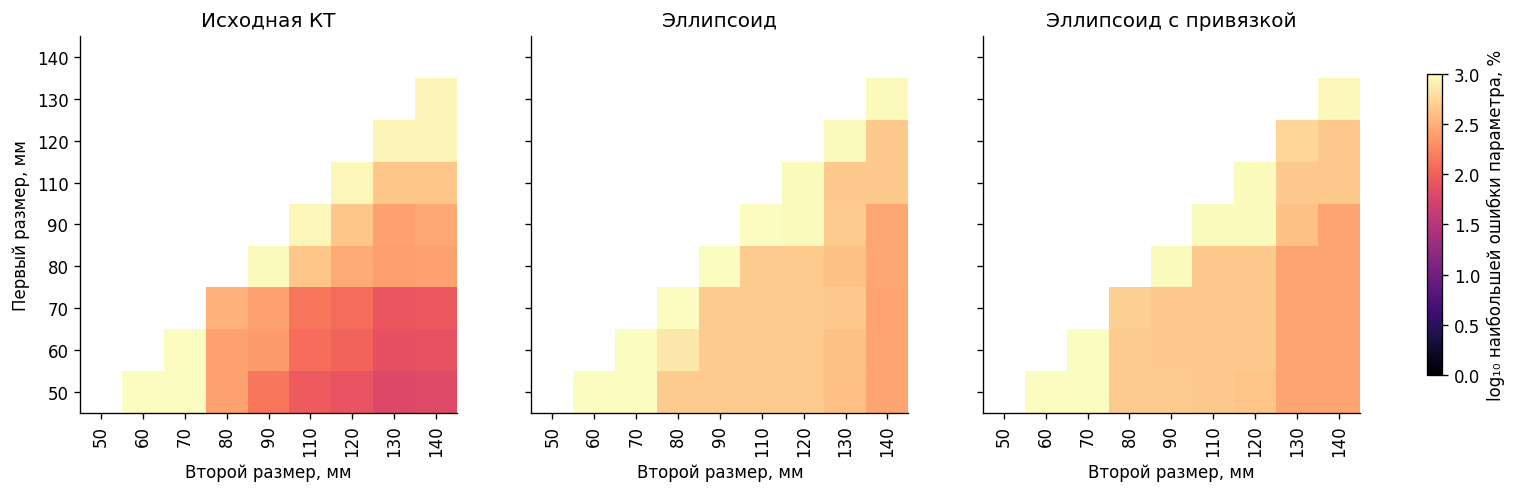

In [11]:
pairs=pd.read_csv(OUT/'pair_recovery.csv')
ranked=pairs.groupby(['model','L1_mm','L2_mm'],sort=False).agg(
    worst_parameter_error_at_1pct_pct=('worst_parameter_error_at_1pct_pct','max'),
    holdout_rmse_ohm=('holdout_rmse_ohm','max'),
    bound=('contrast_at_bound','max')).reset_index()
best=ranked.sort_values('worst_parameter_error_at_1pct_pct').groupby('model',sort=False).head(1)
table(best,{'model':'Модель','L1_mm':'Первый размер, мм','L2_mm':'Второй размер, мм','worst_parameter_error_at_1pct_pct':'Наибольшая ошибка параметра при ±1%, %','holdout_rmse_ohm':'Наибольшая ошибка на семи размерах, Ом','bound':'Контраст на границе без возмущения'})
fig,axes=plt.subplots(1,3,figsize=(13,4),sharey=True,layout='constrained')
for ax,name in zip(axes,['reference','ellipsoid','ellipsoid_depth']):
    rows=ranked[ranked.model==name];matrix=np.full((9,9),np.nan)
    for row in rows.itertuples():matrix[np.flatnonzero(sizes==row.L1_mm)[0],np.flatnonzero(sizes==row.L2_mm)[0]]=row.worst_parameter_error_at_1pct_pct
    pic=ax.imshow(np.log10(matrix),origin='lower',cmap='magma',vmin=0,vmax=3)
    ax.set(xticks=range(9),yticks=range(9),xticklabels=sizes.astype(int),yticklabels=sizes.astype(int),xlabel='Второй размер, мм',title={'reference':'Исходная КТ','ellipsoid':'Эллипсоид','ellipsoid_depth':'Эллипсоид с привязкой'}[name]);ax.tick_params(axis='x',rotation=90)
axes[0].set_ylabel('Первый размер, мм')
fig.colorbar(pic,ax=list(axes),label='log₁₀ наибольшей ошибки параметра, %',shrink=.8)
plt.show()


### Рисунок 7. Устойчивость всех пар размеров в сценарии ±1%

**Что показано.** Каждая заполненная ячейка задаёт пару: первый размер
читается по вертикали, второй — по горизонтали. Три панели относятся
к исходной КТ, эллипсоиду и эллипсоиду с привязкой. Для каждой пары
показан наихудший результат среди трёх заданных контрастов и четырёх
комбинаций знаков возмущения двух импедансов. В каждом случае выбирается
большая по модулю относительная ошибка из $\rho_1$ и $\rho_2$.

**Как анализировать.** Цвет показывает десятичный логарифм этой ошибки,
записанной числом в процентах: 0 означает 1%, 1 — 10%, 2 — 100%,
3 — 1000%. Более тёмные ячейки соответствуют меньшим ошибкам. Шкала
общая; за пределами 1–1000% цвет насыщается, но сами численные ошибки
в сохранённой таблице не обрезаются. Пустая половина исключает повтор
перестановок тех же пар, диагональ не используется. Это не карта
отсутствующих измерений. Таблица перед рисунком показывает лучшую пару
каждой модели по данной метрике и отдельно — максимальный остаток
на семи неиспользованных размерах **без возмущения**. Признак попадания
контраста на границу в таблице также относится к невозмущённым случаям.

**Результат модели.** Для исходной КТ лучшая пара по принятому критерию —
50 и 130 мм, но даже у неё максимальная ошибка параметра составляет
около 61,6% при заданном испытании ±1%. У эллипсоида лучшая пара
50 и 140 мм даёт около 272,2%, у привязанного эллипсоида пара
70 и 140 мм — около 268,9%. Таким образом, добавление привязки по
глубине улучшает номинальное восстановление по девяти размерам, но
не делает проверенную двухразмерную задачу устойчивой в этом испытании.

**Допущения и ограничения.** Один процент — выбранная амплитуда
возмущения, а не измеренная погрешность прибора и не стандартное отклонение
шума. Метрика объединяет смещение от модели и изменение оценки при
возмущении; их отдельные вклады по этому цвету не определяются.
Проверены четыре угловые комбинации ±1%, а не все значения внутри
непрерывного квадрата возмущений. Максимум по ним не является доказанной
верхней границей ошибки на всём квадрате или доверительным интервалом.
Пара выбрана на тех же трёх сценариях; независимая проверка её переноса
ещё нужна.

**Следующий шаг.** Сначала использовать полный размерный ряд для
проверки достаточности геометрии и разделимости тканей. Затем отбирать
пару с учётом диапазона сопротивлений, контактов и воспроизводимости
монтажа, проверяя её на дополнительных сценариях. При недостаточной
устойчивости следует рассмотреть больше измерений либо независимо
доступное ограничение на геометрию или одно сопротивление и оценить
ошибку самого такого ограничения.

## 11. Перенос точечного оператора на данные конечных контактов

Отдельная инверсия использует ранее воспроизведённый CEM-ряд при номинальных
сопротивлениях. Его обработка точечными моделями показывает, какие
параметрические смещения появляются при несовпадении электродных условий.
Этот результат нельзя смешивать с основным опытом, где референс и
пространственные упрощения имеют одинаковые точечные контакты.


In [12]:
cem_inverse=pd.read_csv(OUT/'cem_target_recovery.csv')
table(cem_inverse,{'model':'Модель инверсии','rho1':'ρ₁, Ом·м','rho2':'ρ₂, Ом·м','rho1_error_pct':'Ошибка ρ₁, %','rho2_error_pct':'Ошибка ρ₂, %','all_rmse':'Остаток по девяти размерам, Ом'})


,Модель инверсии,"ρ₁, Ом·м","ρ₂, Ом·м","Ошибка ρ₁, %","Ошибка ρ₂, %","Остаток по девяти размерам, Ом"
0,КТ: исходная граница лёгкого,5.8664,26.4815,5.65963,-13.7605,4.51093
1,Плоская граница в объёме тела,5.99261,10.8957,7.93279,-64.517,4.53796
2,Эллипсоид по объёму и моментам,5.89988,46.8328,6.26267,52.5153,4.50296
3,Эллипсоид с привязкой по глубине,5.88073,37.7288,5.91779,22.8675,4.50072
4,Аналитика: постоянная глубина,5.91946,26.6529,6.61532,-13.2023,4.64781
5,Аналитика: средняя глубина по паре,5.92117,25.7,6.64616,-16.3057,4.64808
6,Аналитика: среднее двухслойное ядро,5.93045,25.9507,6.8133,-15.4891,4.65296
7,Аналитика: конечная толщина лёгкого,5.76857,42.32,3.89759,37.819,4.69216


**Интерпретация таблицы переноса.** Даже точечная модель с исходной
КТ-геометрией даёт для CEM-наблюдений смещение $\rho_1$ около +5,66%,
$\rho_2$ около −13,76% и остаток 4,511 Ом. Геометрия лёгкого в этой
строке не заменялась, поэтому различие связано с несовпадением
электродной постановки, включая дискретное совмещение. Это результат
модели, не метрологическая оценка контакта на коже. Улучшение геометрии
лёгкого необходимо проверять вместе с пригодностью используемого
электродного оператора. Сначала следует согласовать эти условия,
а затем повторять количественное сравнение упрощений.

## 12. Вычислительная стоимость и воспроизведение

Подготовка объёмных и контактных матриц, расчёт библиотеки и последующая
инверсия являются разными затратами. После построения библиотеки подбор
сопротивлений выполняется одномерной интерполяцией и минимизацией;
объёмная FEM-система в каждой итерации не решается. Поэтому этот опыт
реализует ускорение для фиксированной подготовленной геометрии.

Время FEM ниже получено суммированием зарегистрированного времени разложения
и решения всех размеров по контрастам и геометриям. Оно не включает запуск
MATLAB, геометрическую подготовку, загрузку файлов и дополнительные CEM/QC
задачи. Время инверсии — медиана 21 повторения при загруженной библиотеке.
Эти величины не представляют универсального ускорения на другом оборудовании.

В частности, 116 разложений относятся к подготовке библиотеки четырёх
пространственных вариантов. Время около 420 с не является временем
одной инверсии. Медиана около 0,000387 с относится к последующему подбору
при уже загруженной библиотеке и фиксированной геометрии. Практический
вывод ограничен этой постановкой: повторный подбор сопротивлений можно
выполнять без нового объёмного решения на каждой итерации, но получение
оператора для другой геометрии здесь остаётся отдельной затратой.


In [13]:
display(pd.DataFrame({
    'Показатель':['Разложения для библиотеки пространственных моделей','Время решения библиотеки без подготовки, с','Медиана одной инверсии по девяти размерам, с'],
    'Значение':[summary['FEM_library_factorizations'],summary['FEM_library_elapsed_seconds'],summary['online_inverse_median_seconds']]}))


,Показатель,Значение
0,Разложения для библиотеки пространственных моделей,116.000000
1,"Время решения библиотеки без подготовки, с",420.412554
2,"Медиана одной инверсии по девяти размерам, с",0.000387


Полный пересчёт выполняется в канонической MATLAB/Python-ветке. Сначала
подготавливаются геометрические маски, затем профиль `geometry_reduction`
единой точки входа `run_pipeline` рассчитывает библиотеку, после чего
Python-анализ строит обратные оценки. Точные команды приведены в
[документации расчётных стадий](../MATLAB_TRKG4_real_subjects/docs/PIPELINE_FOR_NOTEBOOKS.md).
Обычное выполнение этого ноутбука проверяет контрольные суммы, повторяет
номинальную инверсию и строит таблицы с рисунками по сохранённым результатам.
Полный перебор пар и FEM при этом автоматически не запускаются.

Результаты, исходная геометрия и контрольные суммы хранятся в отдельной
исследовательской папке. Ноутбук с индивидуальными результатами и его
читательский HTML исключены из Git. Это локальное исследование не является
разрешением на публикацию анатомии или исходных медицинских данных.


## 13. Почему совпадение импеданса не гарантирует правильные сопротивления

### 13.1. Численный пример из этого опыта

Известные свойства синтетического объекта:
$\rho_1^*=5,55217$ и $\rho_2^*=30,70695$ Ом·м.
Эллипсоид при этих же сопротивлениях воспроизводит девять импедансов
со среднеквадратичным расхождением 1,966 Ом. После подбора сопротивлений
расхождение уменьшается до 0,275 Ом, но найдено
$\widehat\rho_1=5,58927$ и $\widehat\rho_2=65,42599$ Ом·м.
Ошибка лёгочного сопротивления равна +113,07%: вместо известного
материала модель использует более чем вдвое большее сопротивление.

Относительное расхождение в пространстве наблюдений равно

$$e_Z=100\frac{\lVert\widehat{\mathbf Z}-\mathbf y\rVert_2}
{\lVert\mathbf y\rVert_2}\%\approx0{,}389\%,$$
где $\mathbf y$ — вектор девяти исходных импедансов, Ом,
$\widehat{\mathbf Z}$ — вектор их воспроизведения после
подбора. Это отдельная относительная метрика в пространстве наблюдений,
а не ошибка $\rho_2$. Для размера 140 мм она проявляется так:
исходный импеданс равен 50,495 Ом, расчёт эллипсоида при заданных
сопротивлениях — 48,734 Ом, после подгонки — 50,999 Ом. Подбор заметно
исправляет отклик, используя при этом неверные свойства материала.

Поэтому фразу «хороший прогноз базового импеданса» для рисунка 4 следует
уточнить: **хорошо воспроизведён ряд, использованный при подгонке**.
Проверка независимого прогноза на остальных семи размерах выполняется
в разделе 10. Ни малый обучающий остаток, ни малый проверочный остаток
сами по себе не доказывают правильность параметров, если разные
операторы и параметры дают близкие наблюдения.

### 13.2. Как геометрическая ошибка переходит в ошибку ткани

Импеданс зависит одновременно от свойств материалов, их распределения
в пространстве и электродных условий. Когда геометрия задана ошибочно
и зафиксирована, оптимизатор не может переместить её границу. Он
меняет доступные $\rho_1$ и $\rho_2$, уменьшая разность импедансов.
Полученные величины тогда являются эффективными параметрами выбранного
оператора и могут компенсировать часть его геометрической ошибки.

Локально этот механизм выражается следующим образом:

$$\mathbf r\approx\boldsymbol\delta_G+J\,\delta\boldsymbol\theta
-\boldsymbol\varepsilon,\qquad
\delta\widehat{\boldsymbol\theta}\approx
J^+(\boldsymbol\varepsilon-\boldsymbol\delta_G),$$
где $\mathbf r$ — остаток модели относительно данных, Ом;
$\boldsymbol\delta_G$ — разность упрощённого и референсного операторов
при одной истинной паре параметров, Ом; $\boldsymbol\varepsilon$ —
добавленное возмущение данных, Ом; $J$ — Якобиан упрощённого оператора
в исходной точке; $J^+$ — его псевдообратная матрица; $\boldsymbol\theta$
— логарифмические параметры из раздела 9. Выражение для оценки относится
к линейному приближению с полным рангом, равными весами и отсутствием
активных ограничений.

Если значительная часть $\boldsymbol\delta_G$ лежит в пространстве
изменений, создаваемых столбцами $J$, её можно компенсировать изменением
параметров. Остаток окажется малым, хотя параметры сдвинутся. Малое
сингулярное число усиливает такую реакцию в слабо наблюдаемом направлении.
Следовательно, модельная ошибка может быть плохо видна по остатку,
но сильно проявляться в одном из сопротивлений.

Эта формула объясняет локальный механизм и не использована для расчёта
смещения +113%: столь большое смещение получено полной нелинейной
инверсией, а не экстраполяцией производной на большой интервал. В
основном номинальном опыте случайный шум не добавлялся; смещение
существует уже при замене геометрии.

### 13.3. Что уже установлено и как выбирать следующее упрощение

Сравнение различает самоконтроль интерполированного оператора, замену
лёгочной маски при фиксированных контактах, совокупную ошибку плоских
аналитических приближений и перенос между PEM и CEM. Выводы каждого
сравнения относятся к своей постановке.

Привязка эллипсоида к центральной глубине уменьшила номинальную ошибку
$\rho_2$ со 113,07% до 57,33%, а $\rho_1$ — с 0,67% до 0,31%.
Это положительный результат конкретного геометрического изменения,
но остаточная ошибка лёгочного параметра велика. Сохранение объёма и
центрального входа оказалось недостаточным для проверенных сценариев.
При $q^*=8,6$ исходный эллипсоид упирается в границу поиска; его результат
следует оценивать как ограниченный. Даже согласованная исходная геометрия
не обеспечила устойчивость выбранной пары к испытанию ±1%.

Дальнейшее сокращение модели целесообразно проверять последовательно:

1. Согласовать электродные условия и оценить сходимость исходного
   оператора, чтобы различать ошибку контактов и ошибку маски.
2. Вводить по одному геометрическому признаку: продольный профиль
   ближней границы, поперечную кривизну, затем положение конечного края
   лёгкого. Поддиафрагмальная область сохраняет материал $\rho_1$.
3. Сравнивать не только глубины и объём, но и прямой отклик при одинаковых
   сопротивлениях, ошибки обоих восстановленных параметров, соответствие
   Якобианов референсу и прогноз неиспользованных размеров.
4. Выбирать минимальный набор геометрических признаков после задания
   допустимых ошибок и диапазона условий. Только затем исследовать,
   как получить эти признаки без индивидуальной КТ и как ошибка их
   оценки влияет на сопротивления.

Малая ошибка импеданса, большая чувствительность или небольшое число
обусловленности по отдельности не являются достаточными критериями.
Искомое упрощение должно сохранять именно ту информацию об анатомии,
которая позволяет правильно и устойчиво разделять свойства двух тканей.
Это направление следующего исследования, а не уже доказанная достаточность
эллипсоида или любого из аналитических вариантов.
**Приоритет дальнейшего выбора после уточнения автора.** Допустимая
область сопротивлений должна быть задана до практического ранжирования.
Для каждого кандидата нужны результаты инверсии в этой области и
проверка, сохраняется ли приемлемое совпадение импедансов при допустимых
параметрах. Если совпадение достигается лишь за её пределами, кандидат
не проходит этот критерий в проверенных условиях. Прежнее уменьшение
остатка у эллипсоида характеризует математическую компенсацию ошибки
геометрии; само по себе оно не является основанием рекомендовать
эллипсоид для оценки физиологических сопротивлений.

### 13.4. Достигнутое улучшение относительно прежней двуслойной модели

Следующая таблица непосредственно отвечает цели исследования: уменьшилась
ли ошибка сопротивления лёгкого по сравнению с прежним приближением.
В ней приведены **знаковые относительные ошибки $\rho_2$, %**, относительно
известных синтетических значений при трёх контрастах. Ближе к нулю
по модулю — точнее. Строка исходной КТ не включена в отбор упрощений:
она служит численным самоконтролем, а не новым сокращённым описанием.

| Модель | При q = 2,8 | При q = 5,53062 | При q = 8,6 |
|---|---:|---:|---:|
| Прежняя модель: плоские слои, постоянная толщина | +36,15 | -1,81 | -24,04 |
| Плоская граница внутри КТ-тела | -42,95 | -64,75 | -75,17 |
| Эллипсоид по объёмным моментам | +32,04 | +113,07 | +276,22 |
| Эллипсоид с привязкой по глубине | +19,30 | +57,33 | +150,67 |
| Слоистая формула со средней глубиной | +32,96 | -7,78 | -30,74 |
| Среднее двухслойное ядро | +33,57 | -6,26 | -28,95 |
| Конечный лёгочный слой между областями фона | +103,90 | +76,97 | +54,13 |


При номинальном контрасте прежняя модель даёт ошибки $\rho_1$ около
−0,040% и $\rho_2$ около −1,81%. Среди проверенных новых упрощений
ни одно не улучшило одновременно обе эти ошибки в данном случае.
У привязанного эллипсоида ошибка $\rho_2$ равна +57,33%, хотя остаток
импеданса 0,218 Ом значительно меньше прежних 6,134 Ом. Таким образом,
улучшение подгонки импеданса здесь не обеспечило достижения основной
цели — более точного восстановления тканевых сопротивлений.

При меньшем контрасте результат иной: привязанный эллипсоид уменьшает
ошибку $\rho_2$ по модулю с 36,15% до 19,30%, а $\rho_1$ —
с 0,805% до 0,221%. Поэтому геометрическое уточнение имеет полезный
эффект в одном проверенном сценарии. Однако при номинальном и большем
контрастах этот выигрыш не сохраняется. Ни один проверенный новый
кандидат не показал улучшение обоих параметров относительно прежней
модели во всех трёх случаях. Значение +276,22% у исходного эллипсоида
при большом контрасте относится к решению на верхней границе поиска.

Эти выводы относятся к сохранённой инверсии без установленных
физиологических границ. Они фиксируют результат вычислительного опыта,
но пока не выделяют физиологически допустимого победителя. Низкая ошибка
прежней модели только в номинальном случае также не делает её точным
эталоном: при других контрастах её ошибка $\rho_2$ составляет десятки
процентов. Именно эту недостаточную устойчивость точности и требуется
преодолеть следующим геометрическим приближением.

**Проверка следующего кандидата.** Для одного набора известных
физиологически допустимых сопротивлений необходимо сформировать общий
КТ-референс, а затем восстановить параметры прежним и новым способами
с одинаковыми ограничениями. Следует сравнить ошибки обоих сопротивлений,
остаток и прогноз неиспользованных размеров, повторив опыт по заявленному
диапазону состояний и неопределённостей. При исследовании причины улучшения
электродные условия и наружную область нужно дополнительно согласовать.
Преимущество, исчезающее при уточнении КТ/FEM-референса или контактов,
нельзя считать установленным свойством сокращённой модели.

Такой порядок использует прежний метод как исходный уровень для улучшения,
КТ/FEM — как проверяемый численный референс, а независимые измерения —
как последующий источник физической валидации. Настоящий опыт пока показал
недостаточность проверенных упрощений для устойчивого улучшения прежнего
метода на всех трёх сценариях.


In [14]:
nom=inverse.query('case_index==1').set_index('model')
rows=[]
for name in geometry['model_names']:
    r=nom.loc[name]
    rows.append(f"- {MODEL_LABELS[name]}: ошибка ρ₁ **{r.rho1_error_pct:+.4g}%**, ошибка ρ₂ **{r.rho2_error_pct:+.4g}%**, остаток **{r.all_rmse:.3g} Ом**.")
display(Markdown('В номинальном синтетическом случае получены следующие результаты:\n\n'+'\n'.join(rows)))


В номинальном синтетическом случае получены следующие результаты:

- КТ: исходная граница лёгкого: ошибка ρ₁ **+1.015e-06%**, ошибка ρ₂ **+0.0001309%**, остаток **2.85e-07 Ом**.
- Плоская граница в объёме тела: ошибка ρ₁ **+2.428%**, ошибка ρ₂ **-64.75%**, остаток **0.667 Ом**.
- Эллипсоид по объёму и моментам: ошибка ρ₁ **+0.6683%**, ошибка ρ₂ **+113.1%**, остаток **0.275 Ом**.
- Эллипсоид с привязкой по глубине: ошибка ρ₁ **+0.3111%**, ошибка ρ₂ **+57.33%**, остаток **0.218 Ом**.

Не выполнены сходимость по объёмной сетке и размеру внешней области,
непрерывный переход по площади контакта, независимая проверка позы,
перенос на другую анатомию и исключение индивидуальной КТ. Различия
масок на одной сетке являются результатом дискретной математической модели.
Восстановленные числа не представлены как измеренные свойства тканей.

Трёхмерный метод граничных элементов (BEM), модель 2,5D и локальные кривые
поверхности с большим числом геометрических параметров здесь не реализованы.
Их исследование следует продолжать после оценки достаточности геометрического
описания и электродных условий. Полученная библиотека уже позволяет
проверять сопротивления при фиксированной геометрии без повторного FEM
на каждой итерации; перенос библиотеки на другую геометрию отдельно не доказан.

## 14. Методические источники

Физическая постановка, аналитические функции Грина и ограничения исходной
геометрии подробно приведены в [полном отчёте 20.10](20.10_КТ_FEM_локализация_боковых_матриц_МГТУ.ipynb).
Настоящий ноутбук использует то же аналитическое ядро и проверяет сборку
контактной матрицы сопоставлением с EIDORS.

Для перспективы поверхностных методов релевантны работы о
[трёхмерной электроимпедансной томографии с известными внутренними границами](https://pubmed.ncbi.nlm.nih.gov/17260850/) и
[параметризации границ в BEM-инверсии](https://pubmed.ncbi.nlm.nih.gov/17518058/).
Они обосновывают существование соответствующих классов методов и не
валидируют наши электроды, тканевые параметры или эллипсоидальное упрощение.
Это внешние источники, рассмотренные при постановке исследования.

Перед их использованием проверена тематическая коллекция моделей поля
и поиск по всей доступной резервной копии библиотеки Zotero. В ней имеются
работы о влиянии положения и конфигурации электродов, но совпадающие записи
этих двух BEM-источников по названиям не обнаружены. Использовались
метаданные резервного снимка; полнотекстовый просмотр этих локальных работ
в настоящем опыте не проводился.

**Редакционная версия.** Пояснения к семи расчётным рисункам и схеме А, различия классов
моделей, смысл контраста и локальной обусловленности уточнены по
сохранённым расчётным таблицам. Вычислительные ячейки и их результаты
сохранены. Отдельно выполнена только ячейка условной схемы; данная
редактура не является новым FEM-расчётом или новым
экспериментом на добровольце. Дополнительные численные примеры в тексте
получены арифметическим сопоставлением тех же таблиц и локальных производных.
